# 뇌 MRI 종양 분할 (LGG) — 팀 통합본

Kaggle LGG Segmentation (TCIA / TCGA-LGG) · 환자 110명 · 슬라이스 3,929장

## 팀원 기여

| 영역 | 담당 | 내용 |
|---|---|---|
| **실험 설계** | 윤동길 | 5-Fold 환자 단위 교차검증, 파일럿 하이퍼파라미터 탐색, 128px 입력, 전이학습 참고 실험 |
| **검증 프레임** | 본인 | 기관 × 종양비율 층화, 데이터 누수 실증, 3층 지표 체계, 실패 유형 분석, 개선 대책 사전 기각 |
| **심화 분석** | 배지수 | 환자 3D Dice, TP·FP·FN·TN 픽셀 분석, 종양 크기 구간별 성능 |

각 셀 상단에 `# [담당자]` 주석으로 기여를 표시했다.

## 설정 요약

| 항목 | 값 | 근거 |
|---|---|---|
| 입력 크기 | 128 × 128 | 소실 검증 통과 (2절) |
| MIN_PX | 5 | 면적 비율 환산 (256px 기준 20 → 128px 기준 5) |
| 분할 | 환자 단위 + 기관 × 종양비율 층화 | 슬라이스 분할 시 100% 누수 (3절) |
| 교차검증 | 5-Fold, train 74 / val 14 / test 22명 | 폴드당 학습 데이터 확보 |
| 정식화 | 1채널 sigmoid | 이진 분할 표준 |
| 모델 | M0 규칙기반 / U-Net 베이스라인 | 한 번에 하나씩 변경 |

## 임상 전제

의사가 환자 1명의 MRI를 판독하는 상황. 지표 극대화가 아니라 **놓친 종양을 줄이는 것**이 목적이다.

---
# 실행 안내

**위에서 아래로 순서대로 실행하면 된다.** 아래 사전 점검 셀을 먼저 돌려 환경을 확인할 것.

| 단계 | 소요 시간 |
|---|---|
| 0~6절 (정의) | 약 2분 |
| 7절 파일럿 탐색 | 약 5분 |
| 8절 M0 | 약 2분 |
| 9-1절 M1 5-Fold | 약 15분 |
| 9-2절 M2 5-Fold | 약 15분 |
| 10~15절 (분석) | 약 3분 |
| **합계** | **약 40분** (GPU 기준) |

## 필요한 것

- `kaggle_3m` 폴더가 이 노트북 아래 어딘가에 있을 것 (하위 폴더 포함 자동 탐색)
- 라이브러리: `torch`, `numpy`, `pandas`, `opencv-python`, `matplotlib`, `seaborn`, `scikit-learn`, `tqdm`
- GPU 권장 (CPU 로도 동작하나 매우 느림)

## 건너뛰면 안 되는 셀

- **7절 파일럿** — `BEST_LR`, `BEST_LOSS` 를 정한다. 건너뛰면 9절에서 `NameError`
- **8절 M0** — `M0_RESULT` 를 만든다. 10절 비교표에서 사용
- **9-1, 9-2절** — 둘 다 돌려야 12절 가설검정(M1 vs M2)이 동작한다


In [2]:
# [본인] 사전 점검 — 실행 전에 이 셀부터 돌릴 것
import sys, os, importlib
from glob import glob

print("=== 1. 라이브러리 ===")
need = {"torch":"torch", "numpy":"numpy", "pandas":"pandas", "cv2":"opencv-python",
        "matplotlib":"matplotlib", "seaborn":"seaborn", "sklearn":"scikit-learn", "tqdm":"tqdm"}
missing = []
for mod, pkg in need.items():
    try:
        m = importlib.import_module(mod)
        print(f"  {mod:12s} {getattr(m, '__version__', '?')}")
    except ImportError:
        missing.append(pkg); print(f"  {mod:12s} 없음")
if missing:
    print(f"\n  설치 필요:  pip install {' '.join(missing)}")

print("\n=== 2. 데이터 ===")
cands = sorted(glob("**/kaggle_3m", recursive=True))
if not cands:
    print(f"  kaggle_3m 폴더를 찾지 못했습니다")
    print(f"  현재 작업 디렉토리: {os.getcwd()}")
    print(f"  -> 데이터 압축을 이 폴더 아래에 풀어주세요")
else:
    root = cands[0]
    n_pat = len(glob(os.path.join(root, "TCGA_*")))
    n_tif = len(glob(os.path.join(root, "*", "*.tif")))
    print(f"  경로     {root}")
    print(f"  환자     {n_pat}명   (기대 110)")
    print(f"  tif 파일 {n_tif}개  (기대 7858)")
    if len(cands) > 1:
        print(f"  [주의] kaggle_3m 폴더가 {len(cands)}개 — 중복 압축 해제")

print("\n=== 3. GPU ===")
try:
    import torch
    if torch.cuda.is_available():
        print(f"  {torch.cuda.get_device_name(0)}  "
              f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")
    else:
        print("  GPU 없음 — CPU 로 실행됩니다 (매우 느림)")
except ImportError:
    print("  torch 미설치")

print("\n=== 4. 디스크 ===")
import shutil
free = shutil.disk_usage(".").free / 1024**3
print(f"  여유 공간 {free:.1f}GB  (체크포인트 10개 약 350MB 필요)")

ok = (not missing) and cands
print("\n" + ("사전 점검 통과 — 0절부터 순서대로 실행하세요"
              if ok else "위 문제를 해결한 뒤 다시 실행하세요"))


=== 1. 라이브러리 ===
  torch        2.11.0+cu128
  numpy        1.26.4
  pandas       2.3.3
  cv2          4.11.0
  matplotlib   3.10.9


KeyboardInterrupt: 

---
# 0. 준비

`# [본인]` 환경 설정과 재현성 고정. 2~5번 노트북 공통 구조에 GPU 정보 출력을 추가했다.

In [ ]:
# [본인] 라이브러리 · 시드 · device
import os, time, json, platform, gc
from glob import glob

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# [본인] 이진 분류 지표 — 4번 노트북(흉부 X-ray)과 동일한 import
#        accuracy_score 는 의도적으로 제외 (5절에서 근거 제시)
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix)

# 한글 폰트 — OS 자동 선택 (없으면 경고만 뜨고 진행)
import matplotlib.font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
           "Noto Sans CJK KR", "Noto Sans KR"]:
    if _f in _have:
        plt.rcParams["font.family"] = _f
        break
else:
    print("[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("torch :", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))
    print("VRAM  :", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), "GB")
else:
    print("[경고] GPU 미사용 — 학습이 매우 느립니다")
# AMP API — torch 2.4 이전은 torch.cuda.amp 사용
_NEW_AMP = hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler")
def make_scaler(enabled):
    if _NEW_AMP:
        try: return torch.amp.GradScaler("cuda", enabled=enabled)
        except TypeError: pass
    return torch.cuda.amp.GradScaler(enabled=enabled)

def autocast_ctx(enabled):
    if _NEW_AMP:
        try: return torch.amp.autocast("cuda", enabled=enabled)
        except TypeError: pass
    return torch.cuda.amp.autocast(enabled=enabled)

print("np =", np.__name__, "/ pd =", pd.__name__)
print("AMP API :", "torch.amp" if _NEW_AMP else "torch.cuda.amp")

torch : 2.11.0+cu128
device: cuda
GPU   : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM  : 8.0 GB
np = numpy / pd = pandas
AMP API : torch.amp


In [ ]:
# [본인] 결과 캐시 — 한 번 계산한 것은 파일로 저장하고 다음부터 읽는다
#
#   왜 필요한가
#     Run All 을 할 때마다 1,373장 축소 실측·2,000회 증강 추출이 매번 돌아간다.
#     결과가 항상 같은데도 1분 가까이 걸린다.
#
#   어떻게 동작하나
#     ① deps(의존 설정)를 해시로 만들어 파일 이름에 붙인다
#     ② 같은 이름의 파일이 있으면 읽고, 없으면 계산해서 저장한다
#     ③ IMAGE_SIZE 같은 설정이 바뀌면 해시가 달라져 캐시가 자동 무효화된다
#
#   다른 컴퓨터에서도 쓰려면
#     cache/ 폴더를 노트북과 함께 옮기면 된다.
#     JSON 은 텍스트라 파이썬 버전이 달라도 열린다.
#
#   [주의] 제출·발표 전에는 USE_CACHE = False 로 두고 한 번 전체 실행할 것.
#          캐시로 돌린 노트북은 "실행됨"으로 보이지만 실제 계산은 안 한 것이다.

import json, hashlib, pickle, inspect, shutil
from pathlib import Path

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
USE_CACHE = True                      # False 로 두면 항상 다시 계산

def _cache_key(deps, fn=None):
    """설정 + 함수 코드를 합쳐 해시를 만든다. 코드를 고치면 캐시가 무효화된다."""
    payload = {"deps": deps}
    if fn is not None:
        try:
            payload["code"] = inspect.getsource(fn)
        except (OSError, TypeError):
            pass
    blob = json.dumps(payload, sort_keys=True, default=str).encode()
    return hashlib.md5(blob).hexdigest()[:8]

def cached(name, fn, deps=None, as_json=False, verbose=True):
    """
    name    : 캐시 파일 이름
    fn      : 결과를 만드는 함수 (인자 없음)
    deps    : 이 값이 바뀌면 캐시를 버린다
    as_json : True 면 JSON 으로 저장 (텍스트, 버전 안전) / False 면 pickle
    """
    key = _cache_key(deps, fn)
    ext = "json" if as_json else "pkl"
    path = CACHE_DIR / f"{name}_{key}.{ext}"

    if USE_CACHE and path.exists():
        obj = (json.load(open(path, encoding="utf-8")) if as_json
               else pickle.load(open(path, "rb")))
        if verbose: print(f"  [캐시 사용] {name}  ({path.name})")
        return obj

    obj = fn()
    if as_json:
        json.dump(obj, open(path, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    else:
        pickle.dump(obj, open(path, "wb"))
    if verbose: print(f"  [계산 후 저장] {name}  →  {path.name}")
    return obj

def clear_cache(name=None):
    """캐시를 지운다. name 을 주면 그것만, 안 주면 전부."""
    if name is None:
        shutil.rmtree(CACHE_DIR, ignore_errors=True)
        CACHE_DIR.mkdir(exist_ok=True)
        print("캐시 전체 삭제")
    else:
        n = 0
        for p in CACHE_DIR.glob(f"{name}_*"):
            p.unlink(); n += 1
        print(f"캐시 삭제: {name} ({n}개)")

_files = sorted(CACHE_DIR.glob("*"))
print(f"캐시 폴더  {CACHE_DIR.resolve()}")
print(f"USE_CACHE = {USE_CACHE}   저장된 항목 {len(_files)}개")
for p in _files:
    print(f"   {p.name}  ({p.stat().st_size/1024:.1f} KB)")

캐시 폴더  C:\Users\wm032\Documents\MRI\cache
USE_CACHE = True   저장된 항목 6개
   cv_M1_5b4023c7.pkl  (319.7 KB)
   cv_M1a_0f686a41.pkl  (319.7 KB)
   cv_M1b_3b46eef6.pkl  (319.7 KB)
   cv_M2_70a1ca34.pkl  (319.7 KB)
   leak_demo_973dab24.json  (0.2 KB)
   shrink_check_c741784a.json  (27.7 KB)


## 0-1. 하이퍼파라미터

`# [윤동길]` 128px 입력과 5-Fold. `# [본인]` MIN_PX 환산과 재샘플링 비율.

In [ ]:
# [윤동길] 입력 크기와 폴드 수
IMAGE_SIZE  = 128     # 2절 소실 검증 통과. 256 대비 학습 시간 약 1/4
K_FOLDS     = 5       # 폴드당 train 74 / val 14 / test 22명 확보

# [본인] 판정 기준과 재샘플링
MIN_PX      = 5       # 256px 기준 20 을 면적비 1/4 로 환산 (2절에서 검증)
NEG_RATIO   = 1.0     # 종양 1장당 빈 슬라이스 1장 (에폭마다 재샘플링)

# 공통
BASE        = 32
BATCH_SIZE  = 16
EPOCHS      = 30
LR          = 1e-3    # 1절 파일럿 탐색으로 재확인
USE_AMP     = (device.type == "cuda")
PIN_MEMORY  = (device.type == "cuda")
NUM_WORKERS = 0       # 윈도우 주피터는 0이 안전

print(f"IMAGE_SIZE={IMAGE_SIZE}  MIN_PX={MIN_PX}  K_FOLDS={K_FOLDS}")
print(f"BASE={BASE}  BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}  NEG_RATIO={NEG_RATIO}  AMP={USE_AMP}")

IMAGE_SIZE=128  MIN_PX=5  K_FOLDS=5
BASE=32  BATCH=16  EPOCHS=30  NEG_RATIO=1.0  AMP=True


In [ ]:
# [본인] 실행 환경 기록 — 보고서 재현성 항목
import sklearn, matplotlib
ENV = {
    "OS": f"{platform.system()} {platform.release()}",
    "Python": platform.python_version(),
    "torch": torch.__version__, "CUDA": torch.version.cuda,
    "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음",
    "numpy": np.__version__, "pandas": pd.__version__,
    "opencv": cv2.__version__, "sklearn": sklearn.__version__,
    "matplotlib": matplotlib.__version__, "SEED": SEED,
}
for k, v in ENV.items():
    print(f"  {k:11s}: {v}")
with open("env.json", "w", encoding="utf-8") as f:
    json.dump(ENV, f, ensure_ascii=False, indent=2)

  OS         : Windows 10
  Python     : 3.10.11
  torch      : 2.11.0+cu128
  CUDA       : 12.8
  GPU        : NVIDIA GeForce RTX 5060 Laptop GPU
  numpy      : 1.26.4
  pandas     : 2.3.3
  opencv     : 4.11.0
  sklearn    : 1.7.2
  matplotlib : 3.10.9
  SEED       : 42


---
# 1. 데이터 인덱싱과 탐색

`# [본인]` 파일 목록을 표로 만들고 무결성을 검증한다.
`glob` 으로 **마스크를 먼저** 잡고 `_mask` 를 떼어 원본 경로를 만든다 — 원본을 먼저 잡으면
`*.tif` 패턴에 마스크까지 걸린다.

In [ ]:
# [본인] 경로 탐색 + 무결성 검증
EXPECT_PATIENTS, EXPECT_IMAGES, EXPECT_MASKS = 110, 3929, 3929

cands = sorted(glob("**/kaggle_3m", recursive=True))
if not cands:
    raise FileNotFoundError(f"kaggle_3m 폴더를 못 찾았습니다.\n작업 디렉토리: {os.getcwd()}")
if len(cands) > 1:
    print(f"[주의] kaggle_3m 폴더가 {len(cands)}개 — 중복 압축 해제")
ROOT = cands[0]
print("ROOT =", ROOT)

n_patients = len(glob(os.path.join(ROOT, "TCGA_*")))
all_tif    = glob(os.path.join(ROOT, "*", "*.tif"))
n_masks    = len([p for p in all_tif if p.endswith("_mask.tif")])
n_images   = len(all_tif) - n_masks
print(f"환자 {n_patients} / 원본 {n_images} / 마스크 {n_masks}")

problems = []
if n_patients != EXPECT_PATIENTS: problems.append(f"환자 {n_patients} (기대 {EXPECT_PATIENTS})")
if n_images   != EXPECT_IMAGES:   problems.append(f"원본 {n_images} (기대 {EXPECT_IMAGES})")
if n_masks    != EXPECT_MASKS:    problems.append(f"마스크 {n_masks} (기대 {EXPECT_MASKS})")
if problems:
    raise ValueError("무결성 검증 실패:\n  - " + "\n  - ".join(problems))
print("[검증 통과]\n")

records = []
for mask_path in glob(os.path.join(ROOT, "*", "*_mask.tif")):
    img_path = mask_path.replace("_mask.tif", ".tif")
    patient  = os.path.basename(os.path.dirname(mask_path))
    slice_no = int(os.path.basename(img_path).split("_")[-1].replace(".tif", ""))
    records.append({"patient": patient, "slice": slice_no,
                    "image": img_path, "mask": mask_path})

df = pd.DataFrame(records).sort_values(["patient", "slice"]).reset_index(drop=True)
df["inst"] = df["patient"].str.split("_").str[1]      # [본인] 기관 코드 복원
print(f"슬라이스 {len(df)} / 환자 {df['patient'].nunique()} / 기관 {df['inst'].nunique()}")

ROOT = archive\kaggle_3m
환자 110 / 원본 3929 / 마스크 3929
[검증 통과]

슬라이스 3929 / 환자 110 / 기관 5


## 1-1. 클래스 불균형 — 두 층위가 곱해진다

`# [본인]` 슬라이스 단위와 픽셀 단위 불균형을 따로 본다.
4번 노트북(흉부 X-ray)은 불균형이 약 1:3이었으나 본 과제는 1:99다.

In [ ]:
# [본인] 종양 유무와 픽셀 수
def tumor_stats(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return pd.Series({"tumor": int(m.max() > 0), "tumor_px": int((m > 0).sum())})

stats = df["mask"].apply(tumor_stats)
df["tumor"]    = stats["tumor"]
df["tumor_px"] = stats["tumor_px"]

print("[슬라이스 단위]")
print(df["tumor"].value_counts(normalize=True).round(3).to_string())
print()
print("[픽셀 단위]  (원본 256x256 기준)")
print(f"  전체 픽셀 중 종양: {df['tumor_px'].sum() / (len(df)*256*256) * 100:.3f} %")
print()
print("[종양 슬라이스의 종양 비중(%)]")
print((df.loc[df.tumor == 1, "tumor_px"] / (256*256) * 100).describe().round(2).to_string())

[슬라이스 단위]
tumor
0    0.651
1    0.349

[픽셀 단위]  (원본 256x256 기준)
  전체 픽셀 중 종양: 1.030 %

[종양 슬라이스의 종양 비중(%)]
count    1373.00
mean        2.95
std         2.33
min         0.01
25%         1.12
50%         2.33
75%         4.22
max        12.10


함정 ①  불균형이 두 층위로 곱해진다
한 장            256 × 256 = 65,536 px
전체 슬라이스     3,929장   (종양 1,373 / 빈 2,556)
전체 픽셀        3,929 × 65,536 = 257,490,944 px

  종양 픽셀            2,651,854 px
  배경 픽셀          254,839,090 px
  합계              257,490,944 px   = 전체 ✓

[두 층위]
  ① 종양이 있는 슬라이스 비율    34.9453%   (1,373 / 3,929)
  ② 종양 슬라이스 내 평균 비중    2.9471%   (중앙값 2.3331%)
  ① × ②                      1.0299%
  픽셀 단위 실제                1.0299%   <- 일치 ✓

전부 배경 예측 시 픽셀 정확도 = 0.9897

[대표 슬라이스]  TCGA_HT_A61A_20000127  #47
  종양          1,931 px
  화면 전체 대비  2.95%   (분모 65,536 · 뇌 바깥 포함)
  뇌 영역 대비    11.23%   (분모 17,194 · 참고용)


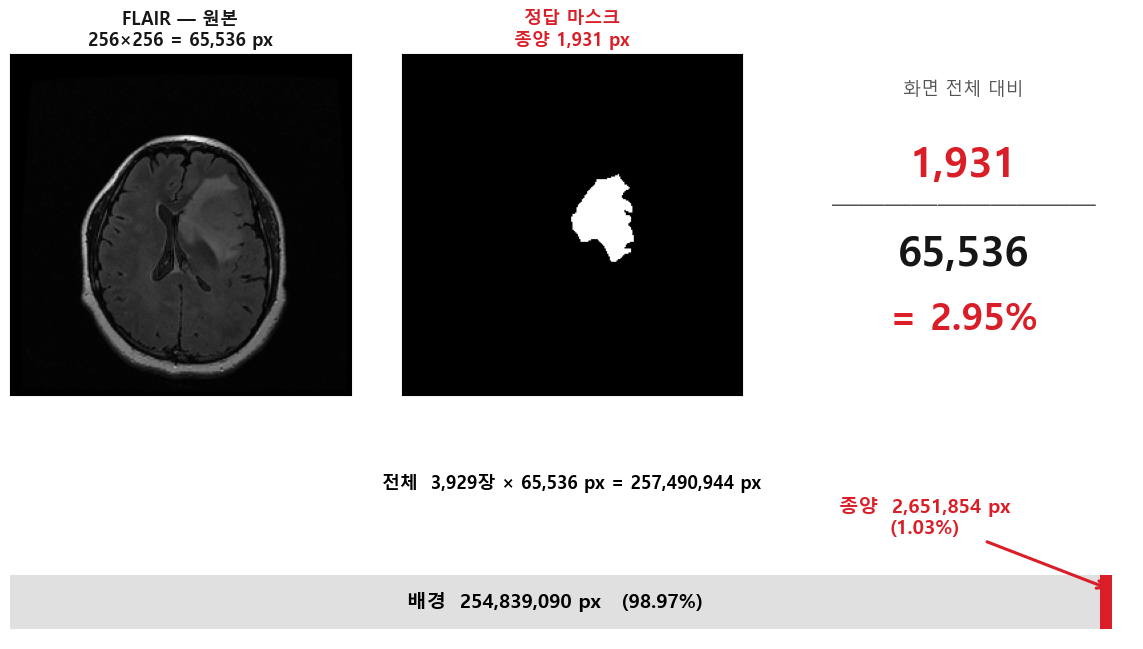


이 숫자가 결정한 세 가지
  ① 정확도 제외          전부 배경 예측 시 0.9897
  ② 손실함수에 Dice 도입   BCE 단독은 '전부 배경'에서도 손실이 낮다
  ③ 빈 슬라이스 재샘플링    슬라이스 불균형 65.1% → 50%


In [ ]:
# ============================================================
# [본인] 함정 ① 불균형 — 슬라이드 7 용
#        · 모든 수치를 한 곳에서 계산하고 assert 로 검증
#        · 대표 슬라이스는 "평균 비중에 가장 가까운 것" 으로 선택
#          (앞 슬라이드의 34.9% × 2.95% = 1.03% 와 숫자를 일치시키기 위함)
#        · 분모는 화면 전체(65,536 px). 뇌 바깥 검은 영역이 포함된다는 점을 명시
# ============================================================
import matplotlib.pyplot as plt

# ---------- 0. 마스크 기준 통일 확인 ----------
#   tumor_px 는 (m > 0), 학습 Dataset 은 (m > 127) 을 쓴다.
#   마스크가 0/255 뿐이면 두 기준이 같아야 한다.
_diff = 0
for _p in df["mask"].head(100):
    _m = cv2.imread(_p, cv2.IMREAD_GRAYSCALE)
    if (_m > 0).sum() != (_m > 127).sum():
        _diff += 1
assert _diff == 0, f"마스크 기준 불일치 {_diff}건 — tumor_px 재계산 필요"

# ---------- 1. 기준 수치 (여기서만 계산) ----------
H = W    = 256
ONE      = H * W                                          # 한 장의 픽셀 수 65,536
N_SLICE  = len(df)
N_POS    = int((df.tumor == 1).sum())
N_NEG    = N_SLICE - N_POS

PX_TOTAL = N_SLICE * ONE
PX_TUMOR = int(df["tumor_px"].sum())
PX_BG    = PX_TOTAL - PX_TUMOR

pos_px   = df.loc[df.tumor == 1, "tumor_px"]
SL_RATE  = N_POS / N_SLICE                                # ① 슬라이스 단위
IN_MEAN  = (pos_px / ONE).mean()                          # ② 슬라이스 내 평균
IN_MED   = (pos_px / ONE).median()                        #    (참고) 중앙값
PX_RATE  = PX_TUMOR / PX_TOTAL                            # ①×②
BG_ACC   = PX_BG / PX_TOTAL                               # 전부 배경 예측 시 정확도

# ---------- 2. 검증 ----------
assert PX_TUMOR + PX_BG == PX_TOTAL,            "픽셀 합 불일치"
assert N_POS + N_NEG == N_SLICE,                "슬라이스 합 불일치"
assert abs(PX_RATE + BG_ACC - 1.0) < 1e-12,     "비율 합이 1이 아님"
assert abs(SL_RATE * IN_MEAN - PX_RATE) < 1e-9, \
       f"두 층위의 곱({SL_RATE*IN_MEAN:.6f})과 실제({PX_RATE:.6f})가 다름"

# ---------- 3. 대표 슬라이스 : 평균 비중에 가장 가까운 것 ----------
target = IN_MEAN * ONE
i      = pos_px.sub(target).abs().idxmin()

img = cv2.imread(df.loc[i, "image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
msk = (cv2.imread(df.loc[i, "mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
PX_ONE = int(msk.sum())
assert PX_ONE == int(df.loc[i, "tumor_px"]), "대표 슬라이스 픽셀 수 불일치"

BR      = int((img[:, :, 1] > 12).sum())                  # 뇌 영역 (참고용)
R_SCREEN = PX_ONE / ONE                                   # 화면 전체 대비
R_BRAIN  = PX_ONE / BR                                    # 뇌 영역 대비

# ---------- 4. 출력 ----------
print("=" * 64)
print("함정 ①  불균형이 두 층위로 곱해진다")
print("=" * 64)
print(f"한 장            {H} × {W} = {ONE:,} px")
print(f"전체 슬라이스     {N_SLICE:,}장   (종양 {N_POS:,} / 빈 {N_NEG:,})")
print(f"전체 픽셀        {N_SLICE:,} × {ONE:,} = {PX_TOTAL:,} px")
print()
print(f"  종양 픽셀      {PX_TUMOR:>15,} px")
print(f"  배경 픽셀      {PX_BG:>15,} px")
print(f"  합계          {PX_TUMOR + PX_BG:>15,} px   = 전체 ✓")
print()
print("[두 층위]")
print(f"  ① 종양이 있는 슬라이스 비율    {SL_RATE*100:7.4f}%   ({N_POS:,} / {N_SLICE:,})")
print(f"  ② 종양 슬라이스 내 평균 비중   {IN_MEAN*100:7.4f}%   (중앙값 {IN_MED*100:.4f}%)")
print(f"  ① × ②                     {SL_RATE*IN_MEAN*100:7.4f}%")
print(f"  픽셀 단위 실제               {PX_RATE*100:7.4f}%   <- 일치 ✓")
print()
print(f"전부 배경 예측 시 픽셀 정확도 = {BG_ACC:.4f}")
print()
print(f"[대표 슬라이스]  {df.loc[i,'patient']}  #{int(df.loc[i,'slice'])}")
print(f"  종양          {PX_ONE:,} px")
print(f"  화면 전체 대비  {R_SCREEN*100:.2f}%   (분모 {ONE:,} · 뇌 바깥 포함)")
print(f"  뇌 영역 대비    {R_BRAIN*100:.2f}%   (분모 {BR:,} · 참고용)")
print("=" * 64)

# ---------- 5. 그림 ----------
ov = img.copy(); ov[msk > 0] = [255, 60, 60]

fig = plt.figure(figsize=(14.5, 7.6))
gs  = fig.add_gridspec(2, 3, height_ratios=[3, 1.25], hspace=.42, wspace=.15)

# 왼쪽 · 가운데 : 실제 슬라이스
for k, (arr, ttl, col) in enumerate([
        (img[:, :, 1], f"FLAIR — 원본\n{H}×{W} = {ONE:,} px", "#161616"),
        (msk,          f"정답 마스크\n종양 {PX_ONE:,} px",      "#DA1E28")]):
    a = fig.add_subplot(gs[0, k])
    a.imshow(arr, cmap="gray")
    a.set_title(ttl, fontweight="bold", fontsize=13, color=col)
    a.set_xticks([]); a.set_yticks([])

# 오른쪽 : 나눗셈
a = fig.add_subplot(gs[0, 2]); a.axis("off")
a.text(.5, .88, "화면 전체 대비", ha="center", fontsize=13, color="#525252")
a.text(.5, .64, f"{PX_ONE:,}", ha="center", fontsize=30, fontweight="bold", color="#DA1E28")
a.text(.5, .535, "──────────", ha="center", fontsize=19, color="#525252")
a.text(.5, .38, f"{ONE:,}", ha="center", fontsize=30, fontweight="bold", color="#161616")
a.text(.5, .19, f"= {R_SCREEN*100:.2f}%", ha="center", fontsize=27,
       fontweight="bold", color="#DA1E28")
# a.text(.5, .05, f"뇌 바깥 검은 영역 포함\n(뇌 영역만 보면 {R_BRAIN*100:.1f}%)",
#        ha="center", fontsize=10, color="#525252")

# 아랫줄 : 전체 픽셀 구성
a = fig.add_subplot(gs[1, :])
a.barh([0], [PX_BG],    color="#E0E0E0", edgecolor="none")
a.barh([0], [PX_TUMOR], left=[PX_BG], color="#DA1E28", edgecolor="none")
a.text(PX_BG/2, 0, f"배경  {PX_BG:,} px   ({BG_ACC*100:.2f}%)",
       ha="center", va="center", fontsize=14, fontweight="bold")
a.annotate(f"종양  {PX_TUMOR:,} px\n({PX_RATE*100:.2f}%)",
           xy=(PX_TOTAL*0.999, 0.18), xytext=(PX_TOTAL*0.83, 1.00),
           ha="center", fontsize=14, fontweight="bold", color="#DA1E28",
           arrowprops=dict(arrowstyle="->", color="#DA1E28", lw=2.2))
a.set_xlim(0, PX_TOTAL*1.02); a.set_ylim(-0.55, 1.55)
a.set_yticks([]); a.set_xticks([])
a.set_title(f"전체  {N_SLICE:,}장 × {ONE:,} px = {PX_TOTAL:,} px",
            fontweight="bold", fontsize=13)
for s in a.spines.values(): s.set_visible(False)

plt.show()

# ---------- 6. 파생 결정 ----------
print()
print("이 숫자가 결정한 세 가지")
print(f"  ① 정확도 제외          전부 배경 예측 시 {BG_ACC:.4f}")
print(f"  ② 손실함수에 Dice 도입   BCE 단독은 '전부 배경'에서도 손실이 낮다")
print(f"  ③ 빈 슬라이스 재샘플링    슬라이스 불균형 {(1-SL_RATE)*100:.1f}% → 50%")

In [ ]:
ONE = 256*256
N   = len(df)
pos = df.loc[df.tumor == 1, "tumor_px"]

sl_rate = (df.tumor == 1).mean()
in_mean = (pos / ONE).mean()          # 평균  ← 슬라이드의 2.95%
in_med  = (pos / ONE).median()        # 중앙값 ← describe 의 2.33%
px_rate = df["tumor_px"].sum() / (N * ONE)

print(f"슬라이스 단위        {sl_rate*100:.4f}%")
print(f"슬라이스 내 평균      {in_mean*100:.4f}%   ← 슬라이드에 쓴 값")
print(f"슬라이스 내 중앙값     {in_med*100:.4f}%   ← describe 출력")
print()
print(f"평균으로 곱하면       {sl_rate*in_mean*100:.4f}%")
print(f"중앙값으로 곱하면      {sl_rate*in_med*100:.4f}%   ← 안 맞음")
print(f"실제 픽셀 단위        {px_rate*100:.4f}%")
print()
assert abs(sl_rate*in_mean - px_rate) < 1e-9, "평균 곱셈 불일치"
print("평균을 곱해야 정확히 일치합니다 ✓")

슬라이스 단위        34.9453%
슬라이스 내 평균      2.9471%   ← 슬라이드에 쓴 값
슬라이스 내 중앙값     2.3331%   ← describe 출력

평균으로 곱하면       1.0299%
중앙값으로 곱하면      0.8153%   ← 안 맞음
실제 픽셀 단위        1.0299%

평균을 곱해야 정확히 일치합니다 ✓


In [ ]:
# [본인] 파일 수준 중복 — 빈 마스크는 내용이 전부 동일하다
n_empty, n_pos = int((df.tumor == 0).sum()), int((df.tumor == 1).sum())
print(f"tif 파일 총          {len(df)*2:,}개")
print(f"내용이 다른 파일      {len(df) + n_pos + 1:,}개")
print(f"  원본 이미지        {len(df):,}개 (전부 고유)")
print(f"  종양 마스크        {n_pos:,}개 (전부 고유)")
print(f"  빈 마스크          {n_empty:,}개 (전부 동일, 256x256 전부 0)")
print(f"\n-> 빈 마스크 비율 {n_empty/len(df):.1%} 가 곧 클래스 불균형이다")

tif 파일 총          7,858개
내용이 다른 파일      5,303개
  원본 이미지        3,929개 (전부 고유)
  종양 마스크        1,373개 (전부 고유)
  빈 마스크          2,556개 (전부 동일, 256x256 전부 0)

-> 빈 마스크 비율 65.1% 가 곧 클래스 불균형이다


## 1-2. 촬영 기관 — 제공되지 않은 정보를 복원

`# [본인]` 환자 식별자 `TCGA_<기관>_<번호>_<날짜>` 의 두 번째 필드가 기관 코드다.
데이터셋에 동봉된 `data.csv` 에는 이 정보가 없다.

In [ ]:
# [본인] 기관별 분포와 FLAIR 밝기
g = df.groupby("inst").agg(환자수=("patient", "nunique"),
                           슬라이스=("patient", "size"),
                           종양비율=("tumor", "mean")).sort_values("환자수", ascending=False)

rows = []
for inst, sub in df.groupby("inst"):
    vals = []
    for p in sub.groupby("patient").head(3)["image"]:
        f = cv2.imread(p, cv2.IMREAD_UNCHANGED)[:, :, ::-1][:, :, 1] / 255.0
        brain = f > 0.05
        if brain.sum() > 0: vals.append(f[brain].mean())
    rows.append({"inst": inst, "FLAIR평균밝기": np.mean(vals)})

print(g.join(pd.DataFrame(rows).set_index("inst")).round(4).to_string())
print()
print("환자당 슬라이스 수")
print(df.groupby(["inst","patient"]).size().groupby(level=0).mean().round(1).to_string())

      환자수  슬라이스    종양비율  FLAIR평균밝기
inst                              
DU     45  1878  0.3323     0.1905
HT     34  1029  0.3926     0.2363
CS     16   358  0.3380     0.2445
FG     14   640  0.3406     0.2396
EZ      1    24  0.2500     0.2506

환자당 슬라이스 수
inst
CS    22.4
DU    41.7
EZ    24.0
FG    45.7
HT    30.3


기관마다 FLAIR 밝기가 최대 28% 차이난다. 스캐너와 프로토콜이 다르기 때문이며,
**이 정보를 3절 분할의 층화 기준으로 사용한다.**

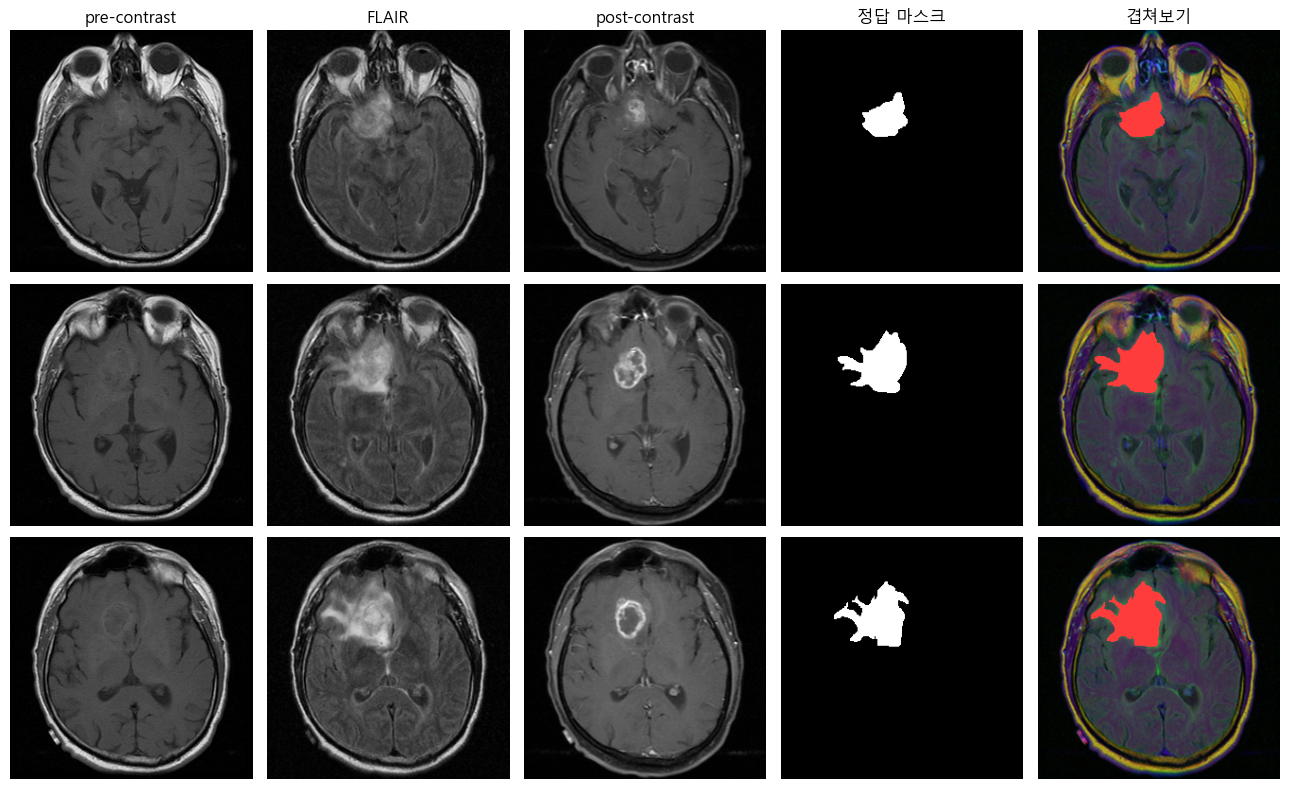

In [ ]:
# [본인] 눈으로 확인 — 3채널은 RGB가 아니라 서로 다른 촬영 기법
idx = df.index[df.tumor == 1][:3]
plt.figure(figsize=(13, 8))
for r, i in enumerate(idx):
    img = cv2.imread(df.loc[i, "image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
    msk = (cv2.imread(df.loc[i, "mask"], 0) > 127).astype(np.uint8)
    ov = img.copy(); ov[msk > 0] = [255, 60, 60]
    for j, (arr, t) in enumerate([(img[:,:,0], "pre-contrast"), (img[:,:,1], "FLAIR"),
                                  (img[:,:,2], "post-contrast"), (msk, "정답 마스크"),
                                  (ov, "겹쳐보기")]):
        plt.subplot(3, 5, r*5 + j + 1)
        plt.imshow(arr, cmap="gray" if arr.ndim == 2 else None); plt.axis("off")
        if r == 0: plt.title(t)
plt.tight_layout(); plt.show()

---
# 2. 입력 크기 결정 — 128px 소실 검증

`# [본인]` 최소 종양이 7픽셀이므로 128 축소 시 정보 손실이 우려되었다.
`# [윤동길]` 128px 로 학습 시간을 1/4 로 줄일 수 있다.

**학습 전에 검증한다.** 마스크를 nearest 보간으로 축소했을 때 종양이 실제로 소실되는지 확인한다.

In [ ]:
# [본인] 128 축소 시 종양 소실 검증 (학습 불필요)
#        결과가 항상 같으므로 캐시한다. IMAGE_SIZE / MIN_PX 가 바뀌면 자동 재계산.

def _shrink_check():
    pos = df[df.tumor == 1]
    rows = []
    for _, r in tqdm(pos.iterrows(), total=len(pos), desc="축소 검증", leave=False):
        mk = (cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        sm = cv2.resize(mk, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        rows.append({"orig": int(mk.sum()), "small": int(sm.sum())})
    return pd.DataFrame(rows).to_dict("list")        # JSON 저장을 위해 dict 로

_sz = cached("shrink_check", _shrink_check,
             deps={"size": IMAGE_SIZE, "n_pos": int((df.tumor == 1).sum()), "root": str(ROOT)},
             as_json=True)
sz = pd.DataFrame(_sz)
sz["ratio"] = sz["small"] / sz["orig"].clip(lower=1)

LOST   = int((sz["small"] == 0).sum())
R_MEAN = float(sz["ratio"].mean())
MIN_O  = int(sz["orig"].min())
MIN_S  = int(sz.loc[sz["orig"].idxmin(), "small"])
D256   = int((sz["orig"]  < 20).sum())
D128   = int((sz["small"] < MIN_PX).sum())

print(f"\n종양 슬라이스 {len(sz):,}장")
print(f"완전 소실 (0px)        {LOST}장  ({LOST/len(sz)*100:5.2f}%)")
print(f"축소 후 5px 미만       {int((sz['small']<5).sum())}장  ({(sz['small']<5).mean()*100:5.2f}%)")
print(f"축소 후 10px 미만      {int((sz['small']<10).sum())}장  ({(sz['small']<10).mean()*100:5.2f}%)")
print(f"축소 후 20px 미만     {int((sz['small']<20).sum())}장  ({(sz['small']<20).mean()*100:5.2f}%)")
print(f"평균 면적 축소율     {R_MEAN:.4f}   (이론값 0.25)")
print(f"원본 최소 종양       {MIN_O}px -> 축소 후 {MIN_S}px")
print(f"MIN_PX 환산 검증")
print(f"  256px 원본, MIN_PX=20 탈락: {D256:2d}장 ({D256/len(sz)*100:.2f}%)")
print(f"  {IMAGE_SIZE}px 축소, MIN_PX={MIN_PX}  탈락: {D128:2d}장 ({D128/len(sz)*100:.2f}%)")

assert LOST == 0, f"완전 소실 {LOST}장 — {IMAGE_SIZE}px 채택 재검토 필요"
assert abs(R_MEAN - 0.25) < 0.05, f"축소율 이상 {R_MEAN:.4f}"
assert abs(D256 - D128) <= 3, "MIN_PX 환산이 공정하지 않음"

  [캐시 사용] shrink_check  (shrink_check_c741784a.json)

종양 슬라이스 1,373장
완전 소실 (0px)        0장  ( 0.00%)
축소 후 5px 미만       2장  ( 0.15%)
축소 후 10px 미만      6장  ( 0.44%)
축소 후 20px 미만     21장  ( 1.53%)
평균 면적 축소율     0.2503   (이론값 0.25)
원본 최소 종양       7px -> 축소 후 3px
MIN_PX 환산 검증
  256px 원본, MIN_PX=20 탈락:  2장 (0.15%)
  128px 축소, MIN_PX=5  탈락:  2장 (0.15%)


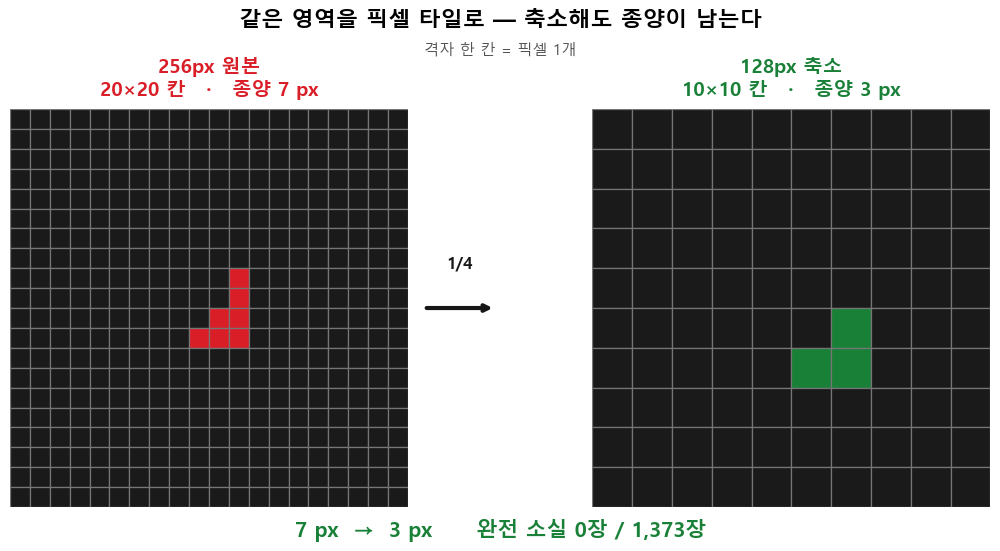

TCGA_FG_A60K_20040224 #36
  256px  7 px
  128px  3 px
  비율   0.429


In [ ]:
# ============================================================
# [본인] 크기 스케일 전후 — 픽셀 타일 (1행 2열, 사례 1개)
#        셀 18(소실 검증) 바로 뒤에 넣을 것
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

WIN = 10                      # 256px 창 = 20×20, 128px 창 = 10×10

def tiles(ax, grid, title, color):
    """0/1 배열을 픽셀 하나당 사각형 하나로 그린다"""
    h, w = grid.shape
    for y in range(h):
        for x in range(w):
            ax.add_patch(Rectangle((x, h-1-y), 1, 1,
                                   facecolor=color if grid[y, x] > 0 else "#1a1a1a",
                                   edgecolor="#767676", linewidth=0.9))
    ax.set_xlim(0, w); ax.set_ylim(0, h); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title(f"{title}\n{w}×{h} 칸   ·   종양 {int(grid.sum())} px",
                 fontweight="bold", fontsize=14, color=color, pad=10)

# ---------- 가장 작은 종양 ----------
pos = df[df.tumor == 1]
i   = pos.tumor_px.idxmin()

mk = (cv2.imread(df.loc[i, "mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
sm = cv2.resize(mk, (128, 128), interpolation=cv2.INTER_NEAREST)

ys, xs = np.where(mk > 0)
cy, cx = int(round(ys.mean())), int(round(xs.mean()))
y0 = max(0, min(256 - 2*WIN, cy - WIN))
x0 = max(0, min(256 - 2*WIN, cx - WIN))

g256 = mk[y0:y0+2*WIN,     x0:x0+2*WIN]
g128 = sm[y0//2:y0//2+WIN, x0//2:x0//2+WIN]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.6))
tiles(ax[0], g256, "256px 원본", "#DA1E28")
tiles(ax[1], g128, "128px 축소", "#198038")

# 가운데 화살표
ax[0].annotate("", xy=(1.22, 0.5), xytext=(1.04, 0.5), xycoords="axes fraction",
               arrowprops=dict(arrowstyle="->", lw=3, color="#161616"))
ax[0].text(1.13, 0.60, "1/4", transform=ax[0].transAxes,
           ha="center", fontsize=12, fontweight="bold", color="#161616")

fig.text(0.5, 0.955, "같은 영역을 픽셀 타일로 — 축소해도 종양이 남는다",
         ha="center", fontsize=16, fontweight="bold")
fig.text(0.5, 0.905, "격자 한 칸 = 픽셀 1개",
         ha="center", fontsize=11, color="#525252")
fig.text(0.5, 0.045,
         f"{int(mk.sum())} px  →  {int(sm.sum())} px      완전 소실 0장 / 1,373장",
         ha="center", fontsize=15, fontweight="bold", color="#198038")

plt.tight_layout(rect=[0, 0.07, 1, 0.89])
plt.savefig("tiles_1x2.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"{df.loc[i,'patient']} #{int(df.loc[i,'slice'])}")
print(f"  256px  {int(mk.sum())} px")
print(f"  128px  {int(sm.sum())} px")
print(f"  비율   {sm.sum()/mk.sum():.3f}")

### 검증 결과 해석

**완전 소실 0장.** nearest 보간은 최근접 픽셀을 그대로 취하므로 소수 픽셀 종양도 보존된다.
최소 종양 7픽셀은 3픽셀로 남았다(이론상 1.75px).

**평균 축소율 0.2503** 으로 이론값(0.25)과 일치한다 — 작은 종양만 유독 손해 보는 편향이 없다.

**MIN_PX 환산도 검증되었다.** 256px 기준 20px 미만 탈락률과 128px 기준 5px 미만 탈락률이
0.15%로 동일하다. 따라서 `MIN_PX=5` 가 공정한 환산이다.

> 입력 크기 128px 채택. 정보 손실 우려는 실측으로 기각되었다.

---
# 3. 데이터 분할

`# [본인]` 환자 단위 + 기관 × 종양비율 층화.
`# [윤동길]` 5-Fold 교차검증 구조.

**이 절이 프로젝트에서 가장 중요하다.** 여기서 실수하면 이후 모든 결과가 무의미해진다.

## 3-1. 슬라이스 단위 분할의 위험 실증

`# [본인]` 4번 노트북(흉부 X-ray)의 `torch.randperm` 방식을 그대로 적용하면 어떻게 되는지 확인한다.
X-ray는 영상 한 장이 환자 한 명이므로 그 방식이 타당했으나, MRI는 환자당 평균 35.7장이다.

In [ ]:
# [본인] 잘못된 방식 재현 — 실제 학습에는 사용하지 않는다

def _leak_demo():
    g = torch.Generator().manual_seed(SEED)
    perm = torch.randperm(len(df), generator=g).tolist()
    n_te = int(len(df) * 0.15)
    bad_te, bad_tr = df.iloc[perm[:n_te]], df.iloc[perm[n_te:]]
    te_p, tr_p = set(bad_te.patient), set(bad_tr.patient)
    all_p = set(df.patient)
    missing = sorted(all_p - te_p)
    return {
        "n_te_slice": len(bad_te),
        "n_te_pat":   len(te_p),
        "n_tr_pat":   len(tr_p),
        "n_overlap":  len(tr_p & te_p),
        "n_all":      len(all_p),
        "missing":    [{"patient": p, "n_slice": int((df.patient == p).sum())} for p in missing],
        "per_patient": float(len(df) / df.patient.nunique()),
    }

L = cached("leak_demo", _leak_demo,
           deps={"seed": SEED, "n": len(df), "ratio": 0.15}, as_json=True)

print("[슬라이스 단위로 나눴을 때]")
print(f"  test 슬라이스 {L['n_te_slice']}장 / 환자 {L['n_te_pat']}명")
print(f"  그중 train 에도 존재하는 환자: {L['n_overlap']}명")
print(f"  -> test 환자의 {L['n_overlap']/L['n_te_pat']*100:.0f}% 가 train 에도 존재")
print(f"  환자당 평균 슬라이스: {L['per_patient']:.1f}장")
print(f"  15%를 무작위로 떼면 모든 환자가 양쪽에 걸린다")
if L["missing"]:
    print(f"\n  참고: test 에 한 장도 안 뽑힌 환자 {len(L['missing'])}명")
    for m in L["missing"]:
        print(f"    {m['patient']}  {m['n_slice']}장  "
              f"(안 뽑힐 확률 {(1-0.15)**m['n_slice']:.4f})")

assert L["n_overlap"] == L["n_te_pat"], "중복률이 100%가 아님 — 재현 실패"

  [캐시 사용] leak_demo  (leak_demo_973dab24.json)
[슬라이스 단위로 나눴을 때]
  test 슬라이스 589장 / 환자 109명
  그중 train 에도 존재하는 환자: 109명
  -> test 환자의 100% 가 train 에도 존재
  환자당 평균 슬라이스: 35.7장
  15%를 무작위로 떼면 모든 환자가 양쪽에 걸린다

  참고: test 에 한 장도 안 뽑힌 환자 1명
    TCGA_HT_8113_19930809  21장  (안 뽑힐 확률 0.0329)


## 3-2. 5-Fold 환자 단위 층화 분할

`# [윤동길]` KFold 구조.
`# [본인]` 층화 기준 = 기관 × 종양비율 2분위.

층화가 없으면 특정 기관이 한 폴드에 몰릴 수 있다. 층마다 따로 배분하여 이를 막는다.

**층화 기준을 2개로 제한한 이유** — 환자 110명을 기관 5 × 종양비율 2 = 최대 10층으로 나누면
층당 약 11명이다. 여기에 종양 크기를 추가하면 20층·층당 5.5명이 되어 폴드 배정이 불가능해진다.

In [ ]:
# [이정우] 파일럿 튜닝 전용 홀드아웃 분리 (선택 편향 수정)
# 기존 방식은 fold 0만 파일럿에서 제외했으나, fold 1~4는 이후 5-Fold의 test로도 쓰이므로
# 완전한 격리가 아니었다 (7절에서 발견). 전체 환자의 15%를 K-Fold 대상에서 아예 제외하고
# 파일럿 전용으로 미리 떼어내어, 이후 어떤 fold의 test와도 절대 겹치지 않게 한다.
all_patients_arr = df.drop_duplicates("patient")["patient"].to_numpy()
rng_holdout = np.random.default_rng(SEED)
rng_holdout.shuffle(all_patients_arr)
n_holdout = max(int(len(all_patients_arr) * 0.15), K_FOLDS)
tuning_holdout_patients = all_patients_arr[:n_holdout]
kfold_patients = all_patients_arr[n_holdout:]

print(f"파일럿 전용 홀드아웃: {len(tuning_holdout_patients)}명 (모든 fold의 test에서 완전히 제외)")
print(f"K-Fold 대상: {len(kfold_patients)}명")

# [윤동길] 5-Fold 구조  +  [본인] 기관 x 종양비율 층화 (kfold_patients 에서만 수행)
def group_kfold_split(df, n_splits=K_FOLDS, seed=SEED):
    rng = np.random.default_rng(seed)
    pdf = df.drop_duplicates("patient")[["patient", "inst"]].copy()
    pdf["ratio"]  = pdf["patient"].map(df.groupby("patient")["tumor"].mean())
    pdf["bin"]    = pd.qcut(pdf["ratio"], q=2, labels=False, duplicates="drop")
    pdf["strata"] = pdf["inst"] + "_" + pdf["bin"].astype(str)

    fold_of = {}
    for st, sub in pdf.groupby("strata"):
        ids = sub["patient"].to_numpy(); rng.shuffle(ids)
        for i, p in enumerate(ids):
            fold_of[p] = i % n_splits      # 층마다 0,1,2,3,4 돌아가며 배정
    return df["patient"].map(fold_of)

df_all = df.copy()   # 파일럿에서 홀드아웃 환자의 이미지를 쓰기 위해 원본을 보관해둔다
df = df[df["patient"].isin(kfold_patients)].reset_index(drop=True)   # 이후 모든 fold 작업은 이 df만 사용
df["fold"] = group_kfold_split(df)

print(df.groupby("fold").agg(환자=("patient","nunique"),
                             슬라이스=("patient","size"),
                             종양비율=("tumor","mean")).round(3).to_string())
print()
print("기관 x fold (환자 수)")
print(pd.crosstab(df.drop_duplicates("patient")["inst"],
                  df.drop_duplicates("patient")["fold"]).to_string())
print()
chk = df.groupby("patient")["fold"].nunique()
print(f"두 폴드에 걸친 환자: {(chk > 1).sum()}명 (0이어야 정상)")
assert (chk > 1).sum() == 0, "폴드 배정 오류"


파일럿 전용 홀드아웃: 16명 (모든 fold의 test에서 완전히 제외)
K-Fold 대상: 94명
      환자  슬라이스   종양비율
fold                 
0     23   803  0.326
1     22   806  0.373
2     18   634  0.380
3     16   618  0.312
4     15   519  0.376

기관 x fold (환자 수)
fold  0  1  2  3  4
inst               
CS    4  4  2  2  2
DU    8  8  8  7  7
EZ    1  0  0  0  0
FG    3  3  2  2  1
HT    7  7  6  5  5

두 폴드에 걸친 환자: 0명 (0이어야 정상)


## 3-3. 폴드 내 train / val 분리

`# [윤동길]` test 는 폴드 하나, 나머지 4폴드를 train+val 로 쓰고 그 안에서 val 을 15% 떼어낸다.

> **주의** — test 와 val 에 각각 폴드 하나씩을 배정하면
> 5-Fold 에서 train 이 3폴드(66명)로 줄고, 3-Fold 에서는 1폴드(약 36명)만 남는다.
> 반드시 **train+val 묶음에서 val 을 분리**해야 한다.

In [ ]:
# [윤동길] 폴드별 train/val/test 구성 확인
from sklearn.model_selection import train_test_split

print(f"{'fold':>4} {'train':>7} {'val':>5} {'test':>5}   (환자 수)")
print("-" * 34)
for f in range(K_FOLDS):
    test_p = df.loc[df.fold == f, "patient"].unique()
    rest_p = df.loc[df.fold != f, "patient"].unique()
    tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)
    print(f"{f:>4} {len(tr_p):>7} {len(va_p):>5} {len(test_p):>5}")

fold   train   val  test   (환자 수)
----------------------------------
   0      60    11    23
   1      61    11    22
   2      64    12    18
   3      66    12    16
   4      67    12    15


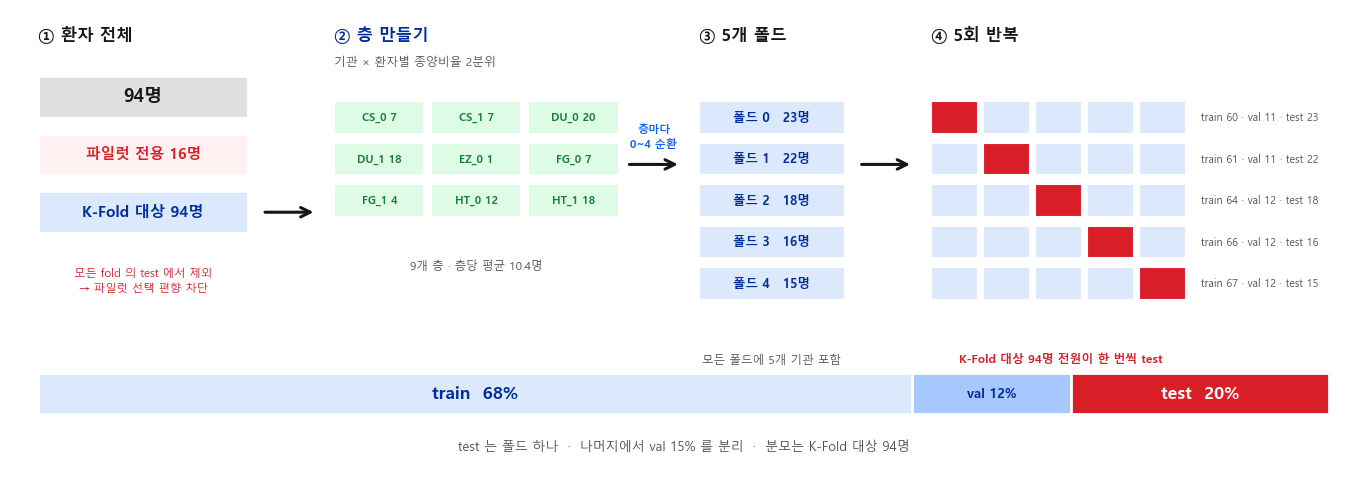

전체 94명 → 파일럿 홀드아웃 16명 / K-Fold 대상 94명

층 9개 · 층당 평균 10.4명
strata
CS_0     7
CS_1     7
DU_0    20
DU_1    18
EZ_0     1
FG_0     7
FG_1     4
HT_0    12
HT_1    18

폴드 크기  [23, 22, 18, 16, 15]   합계 94명
최대/최소 = 1.53배

fold   train   val  test
--------------------------
   0      60    11    23
   1      61    11    22
   2      64    12    18
   3      66    12    16
   4      67    12    15
평균    63.6  11.6  18.8
비율     68%    12%    20%

검증 통과 — 홀드아웃 격리 · 폴드 무결성 · 합계 일치


In [ ]:
# ============================================================
# [본인] 5-Fold 환자 단위 층화 분할 — 전체 과정 시각화
#        셀 26(폴드별 train/val/test 구성 확인) 바로 뒤에 넣을 것
#        필요 변수: df, tuning_holdout_patients, kfold_patients, K_FOLDS, SEED
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

NAVY, BLUE, INK, GRAY = "#002D9C", "#0F62FE", "#161616", "#525252"
RED, LTBLUE, LTRED    = "#DA1E28", "#DCE8FB", "#FFF1F1"
GREEN, LTGREEN, LTGRAY = "#198038", "#DEFBE6", "#E0E0E0"

# ---------- 1. 실제 값 수집 ----------
N_ALL     = df["patient"].nunique()
N_HOLDOUT = len(tuning_holdout_patients)
N_KFOLD   = len(kfold_patients)

pat = df[df.patient.isin(kfold_patients)].drop_duplicates("patient")[["patient", "inst", "fold"]].copy()
pat["ratio"]  = pat["patient"].map(df.groupby("patient")["tumor"].mean())
pat["bin"]    = pd.qcut(pat["ratio"], q=2, labels=False, duplicates="drop")
pat["strata"] = pat["inst"] + "_" + pat["bin"].astype(str)

strata_cnt = pat["strata"].value_counts().sort_index()
fold_n     = [int((pat["fold"] == f).sum()) for f in range(K_FOLDS)]

splits = []
for f in range(K_FOLDS):
    te = df.loc[(df.fold == f) & df.patient.isin(kfold_patients), "patient"].unique()
    rest = np.array([p for p in kfold_patients if p not in set(te)])
    tr, va = train_test_split(rest, test_size=0.15, random_state=SEED)
    splits.append((len(tr), len(va), len(te)))

r_tr = np.mean([s[0] for s in splits]) / N_KFOLD
r_va = np.mean([s[1] for s in splits]) / N_KFOLD
r_te = np.mean([s[2] for s in splits]) / N_KFOLD

# ---------- 2. 그림 ----------
fig, ax = plt.subplots(figsize=(13.5, 4.7))
TOP = 4.86
CW, CH, G = 0.90, 0.36, 0.07

# ══ ① 환자 → 홀드아웃 분리 ══
ax.text(0.28, TOP + 0.34, "① 환자 전체", fontsize=12, fontweight="bold", color=INK)
for k, (txt, cnt, fc, tc, fs) in enumerate([
        (f"{N_ALL}명",                 None, LTGRAY, INK,   13),
        (f"파일럿 전용 {N_HOLDOUT}명",  None, LTRED,  RED,   10.5),
        (f"K-Fold 대상 {N_KFOLD}명",    None, LTBLUE, NAVY,  11)]):
    y = TOP - 0.52 - k * 0.64
    ax.add_patch(Rectangle((0.28, y), 2.10, 0.46, facecolor=fc, edgecolor="white", lw=2))
    ax.text(1.33, y + 0.23, txt, ha="center", va="center",
            fontsize=fs, fontweight="bold", color=tc)

ax.text(1.33, TOP - 2.18, "모든 fold 의 test 에서 제외\n→ 파일럿 선택 편향 차단",
        ha="center", va="top", fontsize=8.2, color=RED, linespacing=1.35)

ax.add_patch(FancyArrowPatch((2.52, TOP - 1.57), (3.06, TOP - 1.57),
                             arrowstyle="->", lw=2.2, color=INK, mutation_scale=17))

# ══ ② 층 만들기 ══
ax.text(3.24, TOP + 0.34, "② 층 만들기", fontsize=12, fontweight="bold", color=NAVY)
ax.text(3.24, TOP + 0.06, "기관 × 환자별 종양비율 2분위", fontsize=8.6, color=GRAY)

names = list(strata_cnt.index)
NCOL  = 3
for k, st in enumerate(names):
    col, row = k % NCOL, k // NCOL
    x = 3.24 + col * (CW + G)
    y = TOP - 0.70 - row * (CH + 0.10)
    ax.add_patch(Rectangle((x, y), CW, CH, facecolor=LTGREEN, edgecolor="white", lw=1.5))
    ax.text(x + CW/2, y + CH/2, f"{st} {strata_cnt[st]}",
            ha="center", va="center", fontsize=8.0, fontweight="bold", color=GREEN)

n_row = (len(names) + NCOL - 1) // NCOL
ax.text(3.24 + (NCOL*(CW+G) - G)/2, TOP - 0.82 - n_row * (CH + 0.10),
        f"{len(names)}개 층 · 층당 평균 {N_KFOLD/len(names):.1f}명",
        ha="center", fontsize=8.4, color=GRAY)

ax.add_patch(FancyArrowPatch((6.16, TOP - 1.04), (6.70, TOP - 1.04),
                             arrowstyle="->", lw=2.2, color=INK, mutation_scale=17))
ax.text(6.43, TOP - 0.88, f"층마다\n0~{K_FOLDS-1} 순환", ha="center", va="bottom",
        fontsize=8, color=BLUE, fontweight="bold", linespacing=1.25)

# ══ ③ 폴드 ══
ax.text(6.88, TOP + 0.34, f"③ {K_FOLDS}개 폴드", fontsize=12, fontweight="bold", color=INK)
for f in range(K_FOLDS):
    y = TOP - 0.70 - f * (CH + 0.10)
    ax.add_patch(Rectangle((6.88, y), 1.46, CH, facecolor=LTBLUE, edgecolor="white", lw=1.6))
    ax.text(7.61, y + CH/2, f"폴드 {f}   {fold_n[f]}명",
            ha="center", va="center", fontsize=9, fontweight="bold", color=NAVY)
ax.text(7.61, TOP - 0.94 - K_FOLDS * (CH + 0.10),
        f"모든 폴드에 {pat['inst'].nunique()}개 기관 포함",
        ha="center", fontsize=8.4, color=GRAY)

ax.add_patch(FancyArrowPatch((8.48, TOP - 1.04), (9.02, TOP - 1.04),
                             arrowstyle="->", lw=2.2, color=INK, mutation_scale=17))

# ══ ④ 반복 ══
ax.text(9.20, TOP + 0.34, f"④ {K_FOLDS}회 반복", fontsize=12, fontweight="bold", color=INK)
cw2, g2 = 0.47, 0.05
for r in range(K_FOLDS):
    y = TOP - 0.70 - r * (CH + 0.10)
    for f in range(K_FOLDS):
        x = 9.20 + f * (cw2 + g2)
        ax.add_patch(Rectangle((x, y), cw2, CH,
                               facecolor=RED if f == r else LTBLUE,
                               edgecolor="white", lw=1.5))
    tr, va, te = splits[r]
    ax.text(9.20 + K_FOLDS*(cw2+g2) + 0.10, y + CH/2,
            f"train {tr} · val {va} · test {te}",
            ha="left", va="center", fontsize=7.6, color=GRAY)
ax.text(10.50, TOP - 0.94 - K_FOLDS * (CH + 0.10),
        f"K-Fold 대상 {N_KFOLD}명 전원이 한 번씩 test",
        ha="center", fontsize=8.6, fontweight="bold", color=RED)

# ══ 하단 비율 막대 ══
ybar, total, x0 = 1.05, 12.9, 0.28
w_tr, w_va, w_te = total*r_tr, total*r_va, total*r_te
for x, w, fc in [(x0, w_tr, LTBLUE), (x0+w_tr, w_va, "#A6C8FF"), (x0+w_tr+w_va, w_te, RED)]:
    ax.add_patch(Rectangle((x, ybar), w, 0.46, facecolor=fc, edgecolor="white", lw=2))
ax.text(x0+w_tr/2,           ybar+0.23, f"train  {r_tr*100:.0f}%", ha="center", va="center",
        fontsize=12.5, fontweight="bold", color=NAVY)
ax.text(x0+w_tr+w_va/2,      ybar+0.23, f"val {r_va*100:.0f}%",    ha="center", va="center",
        fontsize=9.5,  fontweight="bold", color=NAVY)
ax.text(x0+w_tr+w_va+w_te/2, ybar+0.23, f"test  {r_te*100:.0f}%",  ha="center", va="center",
        fontsize=12.5, fontweight="bold", color="white")
ax.text(x0+total/2, 0.65,
        f"test 는 폴드 하나  ·  나머지에서 val 15% 를 분리  ·  분모는 K-Fold 대상 {N_KFOLD}명",
        ha="center", fontsize=9.4, color=GRAY)

ax.set_xlim(0, 13.4); ax.set_ylim(0.42, TOP + 0.68); ax.axis("off")
plt.tight_layout(pad=0.3)
plt.savefig("fold_structure.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ---------- 3. 확인 출력 ----------
print(f"전체 {N_ALL}명 → 파일럿 홀드아웃 {N_HOLDOUT}명 / K-Fold 대상 {N_KFOLD}명")
print(f"\n층 {len(names)}개 · 층당 평균 {N_KFOLD/len(names):.1f}명")
print(strata_cnt.to_string())
print(f"\n폴드 크기  {fold_n}   합계 {sum(fold_n)}명")
print(f"최대/최소 = {max(fold_n)/min(fold_n):.2f}배\n")
print("fold   train   val  test")
print("-" * 26)
for f, (tr, va, te) in enumerate(splits):
    print(f"{f:>4} {tr:>7} {va:>5} {te:>5}")
print(f"평균 {np.mean([s[0] for s in splits]):>7.1f} "
      f"{np.mean([s[1] for s in splits]):>5.1f} {np.mean([s[2] for s in splits]):>5.1f}")
print(f"비율 {r_tr*100:>6.0f}% {r_va*100:>5.0f}% {r_te*100:>5.0f}%")

# ---------- 4. 검증 ----------
assert sum(fold_n) == N_KFOLD, "폴드 합계 불일치"
assert len(set(tuning_holdout_patients) & set(kfold_patients)) == 0, "홀드아웃 누수"
assert df.groupby("patient")["fold"].nunique().max() == 1, "환자가 두 폴드에 걸침"
print("\n검증 통과 — 홀드아웃 격리 · 폴드 무결성 · 합계 일치")

---
# 4. 데이터 적재와 Dataset

`# [본인]` 5번 노트북의 `build_dataset` 구조. 128px 로 리사이즈하며 **마스크는 nearest** 를 쓴다.

In [ ]:
# [본인] 128px 리사이즈 적재  (마스크는 nearest 필수)
def build_dataset(sub_df, desc, size=IMAGE_SIZE):
    imgs = np.zeros((len(sub_df), size, size, 3), dtype=np.uint8)
    msks = np.zeros((len(sub_df), size, size), dtype=np.uint8)
    for i, (_, r) in enumerate(tqdm(sub_df.iterrows(), total=len(sub_df), desc=desc, leave=False)):
        im = cv2.imread(r["image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]   # BGR -> 원래 순서
        mk = (cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        if size != 256:
            im = cv2.resize(im, (size, size), interpolation=cv2.INTER_AREA)
            mk = cv2.resize(mk, (size, size), interpolation=cv2.INTER_NEAREST)
        imgs[i], msks[i] = im, mk
    return imgs, msks


def compute_norm_stats(imgs):
    """[본인] train 에서만, float64 누적 (float32 는 반올림으로 2% 왜곡)"""
    s, ss, n = np.zeros(3), np.zeros(3), 0
    for i in range(0, len(imgs), 500):
        ch = imgs[i:i+500].astype(np.float64).reshape(-1, 3) / 255.0
        s  += ch.sum(0, dtype=np.float64)
        ss += (ch ** 2).sum(0, dtype=np.float64)
        n  += len(ch)
    mean = (s / n).astype(np.float32)
    std  = np.sqrt(ss / n - (s / n) ** 2).astype(np.float32)
    return mean, std

print("build_dataset / compute_norm_stats 정의 완료")

build_dataset / compute_norm_stats 정의 완료


## 4-1. Dataset — 빈 슬라이스 에폭별 재샘플링

`# [본인]` train 의 빈 슬라이스를 다 넣으면 학습이 희석되고, 다 빼면 오탐이 폭발한다.
**매 에폭 다르게 뽑아 섞으므로** 데이터를 버리는 것이 아니라 한 에폭 안의 비율만 조절한다.

증강은 `torchvision.transforms` 를 쓸 수 없다 — 이미지만 뒤집고 마스크는 그대로 두어
정답이 어긋나기 때문이다. numpy 로 직접 구현하여 **이미지와 마스크에 동일한 기하 변환**을 적용한다.

In [ ]:
# [본인] SegDataset — 재샘플링 + 이미지·마스크 동시 증강
class SegDataset(Dataset):
    def __init__(self, imgs, msks, sub_df, mean, std,
                 neg_ratio=None, augment=False, seed=SEED):
        self.imgs, self.msks, self.sub = imgs, msks, sub_df
        self.mean, self.std = mean, std
        self.neg_ratio, self.augment = neg_ratio, augment
        self.pos_idx = np.where(sub_df["tumor"].values == 1)[0]
        self.neg_idx = np.where(sub_df["tumor"].values == 0)[0]
        self.rng = np.random.default_rng(seed)
        self.resample_epoch()

    def resample_epoch(self):
        if self.neg_ratio is None:                 # val / test 는 전체 사용
            self.rows = np.arange(len(self.sub)); return
        k = min(int(len(self.pos_idx) * self.neg_ratio), len(self.neg_idx))
        pick = self.rng.choice(self.neg_idx, size=k, replace=False)
        self.rows = np.concatenate([self.pos_idx, pick])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        j = self.rows[i]
        img = self.imgs[j].astype(np.float32) / 255.0
        msk = self.msks[j].astype(np.float32)

        if self.augment:                            # 기하 변환: 이미지 + 마스크
            if self.rng.random() < 0.5: img, msk = img[:, ::-1], msk[:, ::-1]
            if self.rng.random() < 0.5: img, msk = img[::-1],    msk[::-1]
            k = int(self.rng.integers(4))
            if k: img, msk = np.rot90(img, k), np.rot90(msk, k)
            img, msk = np.ascontiguousarray(img), np.ascontiguousarray(msk)

        img = np.transpose((img - self.mean) / self.std, (2, 0, 1))   # 정규화는 이미지만
        return torch.from_numpy(img).float(), torch.from_numpy(msk)[None].float()

print("SegDataset 정의 완료")

SegDataset 정의 완료


---
# 5. 모델과 손실함수

`# [본인]` 5번 노트북의 U-Net 구조를 이진 분할로 변환.

| 항목 | 5번 (30클래스) | 본 연구 (이진) |
|---|---|---|
| 출력 채널 | 30 | **1** |
| 손실 | CrossEntropyLoss | **BCEWithLogitsLoss + Dice** |
| 마스크 | int64 `(B,H,W)` | **float32 `(B,1,H,W)`** |
| 예측 | `argmax(1)` | **`sigmoid() > threshold`** |

**skip connection 이 필수인 이유** — 인코더는 128→64→32→16→8 로 해상도를 줄인다.
출력은 다시 128×128 이어야 하는데, 8×8 에서 복원하면 위치가 뭉개진다.

In [ ]:
# [본인] U-Net  (5번 노트북 구조 + 2번 노트북 BatchNorm)
def conv2d_block(in_ch, out_ch, kernel_size=3, use_bn=True):
    layers = []
    for i in range(2):
        layers += [nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size,
                             padding=kernel_size // 2, bias=not use_bn)]
        if use_bn: layers += [nn.BatchNorm2d(out_ch)]
        layers += [nn.ReLU(inplace=True)]
    return nn.Sequential(*layers)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.conv = conv2d_block(in_ch, out_ch, use_bn=use_bn)
        self.pool = nn.MaxPool2d(2); self.drop = nn.Dropout(dropout)
    def forward(self, x):
        f = self.conv(x)
        return f, self.drop(self.pool(f))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2, padding=1, output_padding=1)
        self.drop = nn.Dropout(dropout)
        self.conv = conv2d_block(out_ch + skip_ch, out_ch, use_bn=use_bn)
    def forward(self, x, skip):
        return self.conv(self.drop(torch.cat([self.up(x), skip], dim=1)))


class UNet(nn.Module):
    def __init__(self, base=BASE, in_ch=3, n_classes=1, use_bn=True):
        super().__init__()
        b = base
        self.enc1 = EncoderBlock(in_ch, b,   use_bn=use_bn)
        self.enc2 = EncoderBlock(b,     b*2, use_bn=use_bn)
        self.enc3 = EncoderBlock(b*2,   b*4, use_bn=use_bn)
        self.enc4 = EncoderBlock(b*4,   b*8, use_bn=use_bn)
        self.bottleneck = conv2d_block(b*8, b*16, use_bn=use_bn)
        self.dec1 = DecoderBlock(b*16, b*8, b*8, use_bn=use_bn)
        self.dec2 = DecoderBlock(b*8,  b*4, b*4, use_bn=use_bn)
        self.dec3 = DecoderBlock(b*4,  b*2, b*2, use_bn=use_bn)
        self.dec4 = DecoderBlock(b*2,  b,   b,   use_bn=use_bn)
        self.out  = nn.Conv2d(b, n_classes, 1)
        self._init_weights()

    def _init_weights(self):                        # [본인] 2번 노트북 initializer_weights
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        f1, p1 = self.enc1(x); f2, p2 = self.enc2(p1)
        f3, p3 = self.enc3(p2); f4, p4 = self.enc4(p3)
        c = self.bottleneck(p4)
        c = self.dec1(c, f4); c = self.dec2(c, f3)
        c = self.dec3(c, f2); c = self.dec4(c, f1)
        return self.out(c)


_m = UNet()
with torch.no_grad():
    print("출력 shape:", tuple(_m(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)).shape))
print("파라미터  :", f"{sum(p.numel() for p in _m.parameters()):,}")
del _m

출력 shape: (1, 1, 128, 128)
파라미터  : 8,633,441


## 5-1. 손실함수

`# [본인]` BCE 단독은 위험하다 — 종양이 1%뿐이라 "전부 배경"이라 답해도 손실이 낮다.
**Dice 는 배경을 세지 않으므로** 그 함정을 막는다.

**두 가지 함정**

| 함정 | 증상 | 대응 |
|---|---|---|
| 빈 마스크에서 0/0 | nan 발생 → 가중치 전체 오염 | `smooth = 1.0` |
| AMP float16 오버플로 | 픽셀 합이 한계 초과 → 손실 1.0 고정. **오류도 nan도 없음** | `logits.float()` + GradScaler |

In [ ]:
# [본인] BCE + Dice
class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.w, self.s = w_bce, smooth
    def forward(self, logits, target):
        logits, target = logits.float(), target.float()      # AMP 오버플로 방지
        bce = self.bce(logits, target)
        p = torch.sigmoid(logits)
        inter = (p * target).sum(dim=(1, 2, 3))
        den   = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice  = 1 - ((2*inter + self.s) / (den + self.s)).mean()
        return self.w * bce + (1 - self.w) * dice


class BCELoss(nn.Module):
    """[본인] BCE 단독 — 베이스라인용"""
    def __init__(self):
        super().__init__(); self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, target):
        return self.bce(logits.float(), target.float())

print("손실함수 정의 완료")

손실함수 정의 완료


## 5-2. 평가 지표 — 3층 체계

`# [본인]` 지표마다 답하는 질문이 다르다. 하나만 보면 반드시 속는다.

| 층위 | 지표 | 답하는 질문 | 용도 |
|---|---|---|---|
| 외부 비교 | Dice | 선행 연구 대비 어디쯤인가 | 논문·공개 구현 대조 |
| 1층 | **PR-AUC** | 어느 모델이 나은가 | 모델 선택 (임계값 무관) |
| 2층 | recall / precision / 체적비 | 실제 성능은 어떤가 | 운영점 판단 |
| 3층 | 놓친 환자 / 최소 Dice / 편차 | 쓸 수 있는가 | 임상 적용 판단 |

`accuracy_score` 는 제외한다 — 6절 M0 에서 근거를 제시한다.

In [ ]:
# [본인] matplotlib 버전 호환 — 3.9부터 labels -> tick_labels
import matplotlib as _mpl
_MPL_NEW = tuple(int(x) for x in _mpl.__version__.split(".")[:2]) >= (3, 9)
def boxplot_compat(ax, data, labels, **kw):
    key = "tick_labels" if _MPL_NEW else "labels"
    return ax.boxplot(data, **{key: labels}, **kw)

# [본인] 지표 — 누적 후 나누기 (슬라이스별 평균은 작은 종양을 과대 반영)
def dice_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return (2*(p & t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return ((p & t).sum() + smooth) / ((p | t).sum() + smooth)

def pixel_recall(probs, trues, threshold=0.5):
    p, t = probs > threshold, trues > 0.5
    return (p & t).sum() / max(t.sum(), 1)

def volume_ratio(probs, trues, threshold=0.5):
    """예측 체적 / 정답 체적. 1.0이 정확, 2.0이면 2배 과대평가"""
    return (probs > threshold).sum() / max((trues > 0.5).sum(), 1)


@torch.no_grad()
def evaluate_seg(model, loader):
    """[본인] 4번 노트북 evaluation() 구조 — 확률과 정답을 모아 반환"""
    model.eval()
    probs, trues = [], []
    for xb, yb in loader:
        with autocast_ctx(USE_AMP):
            logits = model(xb.to(device))
        probs.append(torch.sigmoid(logits.float()).cpu())
        trues.append(yb)
    return torch.cat(probs).numpy()[:, 0], torch.cat(trues).numpy()[:, 0]


def threshold_sweep(probs, trues, ths=np.arange(0.05, 0.96, 0.05)):
    return pd.DataFrame([{"th": round(float(t), 2),
                          "dice": float(dice_score(probs, trues, t)),
                          "recall": float(pixel_recall(probs, trues, t)),
                          "vol_ratio": float(volume_ratio(probs, trues, t))} for t in ths])

def pick_threshold(sw, tol=0.98):
    """[본인] 최고점이 아니라 고원(최고의 98% 이상) 중앙값 — val 표본이 작아 최고점은 우연일 수 있다"""
    top = sw[sw["dice"] >= sw["dice"].max() * tol]
    return float(top["th"].median())

print("지표 함수 정의 완료")

지표 함수 정의 완료


---
# 6. 학습 함수

`# [본인]` 5번 노트북 `train_unet` 구조에 세 가지를 변경했다.

1. **체크포인트 기준을 val Dice 로** — val_loss 나 픽셀 정확도로 저장하면 "전부 배경" 모델이 최고점으로 남는다
2. **train Dice 도 기록** — 과적합 격차를 보려면 loss 만으로는 부족하다
3. **AMP** — 순전파는 float16, **손실은 autocast 밖에서 float32**

In [ ]:
# [본인] 학습 함수
def train_unet(criterion, tr_ds, tr_ld, va_ld, use_bn=True,
               epochs=EPOCHS, lr=LR, seed=SEED, tag="M"):
    torch.manual_seed(seed); np.random.seed(seed)
    model  = UNet(base=BASE, use_bn=use_bn).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)   # 2번 노트북
    scaler = make_scaler(USE_AMP)

    history = {"loss": [], "train_dice": [], "val_dice": [], "sec": []}
    best, ckpt = -1.0, f"lgg_{tag}.pt"

    for ep in range(1, epochs + 1):
        tr_ds.resample_epoch()                    # 빈 슬라이스를 매 에폭 새로 뽑는다
        model.train()
        t0, run = time.time(), 0.0
        inter = psum = tsum = 0.0

        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            with autocast_ctx(USE_AMP):
                logits = model(xb)
            loss = criterion(logits, yb)           # 손실은 autocast 밖 (float32)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            run += loss.item() * xb.size(0)
            with torch.no_grad():
                p = (torch.sigmoid(logits.float()) > 0.5).float()
                inter += (p * yb).sum().item()
                psum  += p.sum().item(); tsum += yb.sum().item()

        sched.step()
        vp, vt  = evaluate_seg(model, va_ld)
        va_dice = float(dice_score(vp, vt, 0.5))
        for k, v in zip(["loss","train_dice","val_dice","sec"],
                        [run/len(tr_ds), 2*inter/max(psum+tsum,1), va_dice, time.time()-t0]):
            history[k].append(v)
        if va_dice > best:
            best = va_dice; torch.save(model.state_dict(), ckpt)
        if ep % 5 == 0 or ep == 1:
            print(f"  [{tag}] {ep:2d}/{epochs}  loss {history['loss'][-1]:.4f}  "
                  f"train {history['train_dice'][-1]:.4f}  val {va_dice:.4f}  "
                  f"{history['sec'][-1]:.1f}초")

    gap = history["train_dice"][-1] - history["val_dice"][-1]
    print(f"  [{tag}] 최고 val Dice {best:.4f} | 에폭 평균 {np.mean(history['sec']):.1f}초 | "
          f"과적합 격차 {gap:+.4f}")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    return model, history

print("train_unet 정의 완료")

train_unet 정의 완료


---
# 7. 파일럿 하이퍼파라미터 탐색

`# [윤동길]` 본 학습 전에 폴드와 무관한 파일럿 분할로 후보를 짧게 비교한다.
**이 분할은 하이퍼파라미터 선택에만 쓰이고 최종 평가에는 사용하지 않는다.**

In [ ]:
# [윤동길] 파일럿 홀드아웃으로 lr x 손실 조합 비교 (선택 편향 없음 + M1 설정과 BN 일치)
PILOT_EPOCHS = 5

pilot_train_patients, pilot_val_patients = train_test_split(
    tuning_holdout_patients, test_size=0.2, random_state=SEED
)

pdf_tr = df_all[df_all.patient.isin(pilot_train_patients)].reset_index(drop=True)
pdf_va = df_all[df_all.patient.isin(pilot_val_patients)].reset_index(drop=True)
pi_tr, pm_tr = build_dataset(pdf_tr, "Pilot Train")
pi_va, pm_va = build_dataset(pdf_va, "Pilot Val")
p_mean, p_std = compute_norm_stats(pi_tr)

candidates = [
    {"lr": 1e-3, "loss": "BCE"},
    {"lr": 1e-4, "loss": "BCE"},
    {"lr": 1e-3, "loss": "BCE+Dice"},
]
pilot_results = []
for cand in candidates:
    crit = BCELoss() if cand["loss"] == "BCE" else BCEDiceLoss()
    ds = SegDataset(pi_tr, pm_tr, pdf_tr, p_mean, p_std, neg_ratio=NEG_RATIO, augment=True)
    ld = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    vds = SegDataset(pi_va, pm_va, pdf_va, p_mean, p_std, neg_ratio=None, augment=False)
    vld = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    torch.manual_seed(SEED); np.random.seed(SEED)
    m = UNet(base=BASE, use_bn=False).to(device)   # M1(BatchNorm 없음) 설정과 동일하게 맞춤
    opt = torch.optim.Adam(m.parameters(), lr=cand["lr"])
    scaler = make_scaler(USE_AMP)
    best = -1.0
    for ep in range(PILOT_EPOCHS):
        ds.resample_epoch(); m.train()
        for xb, yb in ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            with autocast_ctx(USE_AMP):
                logits = m(xb)
            loss = crit(logits, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        vp, vt = evaluate_seg(m, vld)
        best = max(best, float(dice_score(vp, vt, 0.5)))
    print(f"lr={cand['lr']:<7} loss={cand['loss']:<9} -> {PILOT_EPOCHS}에폭 최고 val Dice = {best:.4f}")
    pilot_results.append({**cand, "val_dice": best})
    del m, ds, ld, vds, vld; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

best_cand = max(pilot_results, key=lambda x: x["val_dice"])
BEST_LR   = best_cand["lr"]
BEST_LOSS = best_cand["loss"]
print(f"\n선택: lr={BEST_LR}, loss={BEST_LOSS} (val Dice={best_cand['val_dice']:.4f})")
print(f"(파일럿은 K-Fold와 완전히 분리된 홀드아웃 {len(tuning_holdout_patients)}명으로만 진행 — 선택 편향 없음)")

del pi_tr, pm_tr, pi_va, pm_va; gc.collect()


Pilot Train:   0%|          | 0/429 [00:00<?, ?it/s]

Pilot Val:   0%|          | 0/120 [00:00<?, ?it/s]

lr=0.001   loss=BCE       -> 5에폭 최고 val Dice = 0.6334
lr=0.0001  loss=BCE       -> 5에폭 최고 val Dice = 0.2428
lr=0.001   loss=BCE+Dice  -> 5에폭 최고 val Dice = 0.6139

선택: lr=0.001, loss=BCE (val Dice=0.6334)
(파일럿은 K-Fold와 완전히 분리된 홀드아웃 16명으로만 진행 — 선택 편향 없음)


0

---
# 8. M0 — 규칙 기반 베이스라인 (학습 없음)

`# [본인]` 2번 노트북에서 SimpleCNN 이전에 SimpleDNN 으로 기준점을 잡은 것과 같은 구조.
FLAIR 강도에 Otsu 임계값을 걸고 가장 큰 덩어리만 남긴다.

**이 결과가 두 가지를 증명한다.**
① 픽셀 정확도는 쓸 수 없다 ② 재현율 단독도 쓸 수 없다

In [ ]:
# [본인] M0 — FLAIR + Otsu + 최대 연결성분
def otsu_predict(img_u8):
    flair = img_u8[:, :, 1]
    brain = flair > 12
    if brain.sum() < 100:
        return np.zeros_like(flair, np.uint8)
    t, _ = cv2.threshold(flair[brain], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pred = ((flair > t) & brain).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(pred, 8)
    if n <= 1: return pred
    k = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (lab == k).astype(np.uint8)


# 전체 110명(=모든 폴드)에 대해 평가 — 학습이 없으므로 분할이 필요 없다
all_sub = df.reset_index(drop=True)
all_imgs, all_msks = build_dataset(all_sub, "M0 전체")
P0 = np.stack([otsu_predict(im) for im in all_imgs]).astype(np.float32)
f0 = (P0.sum(axis=(1,2)) > MIN_PX).astype(int)
t0 = all_sub["tumor"].values

print("=== M0 규칙 기반 (Otsu, 학습 없음) ===")
print(f"픽셀 Dice        {dice_score(P0, all_msks):.4f}")
print(f"픽셀 재현율      {pixel_recall(P0, all_msks):.4f}   <- 경계 품질")
print(f"체적비           {volume_ratio(P0, all_msks):.2f}배  <- 1.0이 정확")
print(f"슬라이스 재현율   {recall_score(t0, f0, zero_division=0):.4f}   <- 놓친 종양")
print(f"슬라이스 정밀도   {precision_score(t0, f0, zero_division=0):.4f}")
print()
print("=== 무학습 하한선 ===")
print(f"전부 배경        Dice 0.0000, 픽셀 정확도 {1 - all_msks.mean():.4f}")
print(f"항상 종양 있음    슬라이스 재현율 1.0000, 정밀도 {t0.mean():.4f}")

M0_RESULT = {
    "dice": float(dice_score(P0, all_msks)),
    "pixel_recall": float(pixel_recall(P0, all_msks)),
    "vol": float(volume_ratio(P0, all_msks)),
    "slice_recall": float(recall_score(t0, f0, zero_division=0)),
    "slice_precision": float(precision_score(t0, f0, zero_division=0)),
    "bg_accuracy": float(1 - all_msks.mean()),
}
del all_imgs, all_msks, P0; gc.collect()

M0 전체:   0%|          | 0/3380 [00:00<?, ?it/s]

=== M0 규칙 기반 (Otsu, 학습 없음) ===
픽셀 Dice        0.1310
픽셀 재현율      0.4449   <- 경계 품질
체적비           5.79배  <- 1.0이 정확
슬라이스 재현율   1.0000   <- 놓친 종양
슬라이스 정밀도   0.3670

=== 무학습 하한선 ===
전부 배경        Dice 0.0000, 픽셀 정확도 0.9896
항상 종양 있음    슬라이스 재현율 1.0000, 정밀도 0.3527


29

### M0 가 증명하는 것

**① 픽셀 정확도는 쓸 수 없다.** 아무것도 예측하지 않아도 0.98 이상이 나온다.
4번(흉부 X-ray)에서 `accuracy_score` 를 쓴 것은 불균형이 1:3이라 타당했으나, 여기는 1:99다.

**② 재현율 단독도 쓸 수 없다.** M0 는 슬라이스 재현율 1.0000 을 달성했지만
체적을 3배 이상 과대예측한다. 종양 픽셀의 3분의 1만 덮으면서 면적은 3배로 그린 것이다.

> **재현율은 목표가 아니라 제약 조건이어야 한다.**

---
# 9. 5-Fold 교차검증

`# [윤동길]` 폴드 구조.
`# [본인]` 폴드마다 데이터 재구성 · 정규화 통계 재계산 · 임계값 재결정.

폴드마다 통계를 다시 계산하는 이유는, 한 번 계산해 재사용하면
그 폴드의 test 환자가 통계에 포함되어 **누수**가 되기 때문이다.

> **전역 상태 보호** — 이 함수는 지역 변수만 사용하며 전역을 덮어쓰지 않는다.

In [ ]:
# [윤동길] 5-Fold 구조  +  [본인] 폴드별 통계·임계값 재계산
def run_cv(criterion_name="BCE", use_bn=True, epochs=EPOCHS, lr=None,
           n_splits=K_FOLDS, tag="CV"):
    lr = lr if lr is not None else BEST_LR
    fold_rows, all_patient_dice, all_slice_records = [], {}, []

    for f in range(n_splits):
        print(f"\n===== Fold {f+1}/{n_splits} =====")
        test_p = df.loc[df.fold == f, "patient"].unique()
        rest_p = df.loc[df.fold != f, "patient"].unique()
        tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)
        print(f"  train {len(tr_p)}명 / val {len(va_p)}명 / test {len(test_p)}명")

        sub = {k: df[df.patient.isin(v)].reset_index(drop=True)
               for k, v in [("train", tr_p), ("val", va_p), ("test", test_p)]}
        arr = {k: build_dataset(sub[k], f"F{f} {k}") for k in sub}
        mean, std = compute_norm_stats(arr["train"][0])   # 이 폴드 train 에서만

        crit = BCELoss() if criterion_name == "BCE" else BCEDiceLoss()
        tr_ds = SegDataset(*arr["train"], sub["train"], mean, std,
                           neg_ratio=NEG_RATIO, augment=True)
        va_ds = SegDataset(*arr["val"],   sub["val"],   mean, std, neg_ratio=None)
        te_ds = SegDataset(*arr["test"],  sub["test"],  mean, std, neg_ratio=None)
        kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
        va_ld = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, **kw)
        te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, **kw)

        model, hist = train_unet(crit, tr_ds, tr_ld, va_ld, use_bn=use_bn,
                                 epochs=epochs, lr=lr, tag=f"{tag}_f{f}")

        vp, vt = evaluate_seg(model, va_ld)              # 임계값은 이 폴드 val 에서만
        t = pick_threshold(threshold_sweep(vp, vt))

        tp_, tt_ = evaluate_seg(model, te_ld)
        te_sub = sub["test"]
        has  = te_sub["tumor"].values.astype(bool)
        pf   = ((tp_ > t).sum(axis=(1,2)) > MIN_PX).astype(int)
        area = (tp_ > t).sum(axis=(1,2)) / IMAGE_SIZE**2

        # [배지수] 슬라이스별 TP/FP/FN/TN 기록
        pred_b, true_b = tp_ > t, tt_ > 0.5
        for i in range(len(te_sub)):
            tp_i = int((pred_b[i] &  true_b[i]).sum()); fp_i = int((pred_b[i] & ~true_b[i]).sum())
            fn_i = int((~pred_b[i] & true_b[i]).sum()); tn_i = int((~pred_b[i] & ~true_b[i]).sum())
            den = 2*tp_i + fp_i + fn_i
            all_slice_records.append({
                "fold": f, "patient": te_sub.loc[i, "patient"], "slice": int(te_sub.loc[i, "slice"]),
                "tp": tp_i, "fp": fp_i, "fn": fn_i, "tn": tn_i,
                "tumor_px": tp_i + fn_i, "pred_px": tp_i + fp_i,
                "dice": float(2*tp_i/den) if den else 1.0,
            })

        missed = 0
        for p, gp in te_sub.groupby("patient"):
            k = gp.index.values
            all_patient_dice[p] = float(dice_score(tp_[k], tt_[k], t))
            if (has[k] & (pf[k] == 0)).any(): missed += 1

        fold_rows.append({
            "fold": f, "th": round(t, 2), "n_test": len(test_p),
            "dice": float(dice_score(tp_, tt_, t)),
            "dice_pos": float(dice_score(tp_[has], tt_[has], t)),
            "iou": float(iou_score(tp_, tt_, t)),
            "recall": recall_score(has.astype(int), pf, zero_division=0),
            "precision": precision_score(has.astype(int), pf, zero_division=0),
            "prauc": average_precision_score(has.astype(int), area),
            "vol": float(volume_ratio(tp_, tt_, t)),
            "missed": missed,
            "gap": hist["train_dice"][-1] - hist["val_dice"][-1],
        })
        r = fold_rows[-1]
        print(f"  Fold{f}  th {r['th']:.2f}  Dice {r['dice']:.4f}  recall {r['recall']:.4f}  "
              f"PR-AUC {r['prauc']:.4f}  놓친환자 {missed}/{len(test_p)}")

        del arr, tr_ds, va_ds, te_ds, tr_ld, va_ld, te_ld, model; gc.collect()
        if device.type == "cuda": torch.cuda.empty_cache()

    return pd.DataFrame(fold_rows), all_patient_dice, pd.DataFrame(all_slice_records)

print("run_cv 정의 완료")

run_cv 정의 완료


## 9-1. M1 — BCE 단독 베이스라인 (5-Fold)

In [ ]:
# 셀 47
# [윤동길] 5-Fold 실행  ·  [본인] M1 = 5번 노트북 구조 (BCE 단독, BatchNorm 없음)
_CV_DEPS = {"size": IMAGE_SIZE, "epochs": EPOCHS, "lr": BEST_LR, "neg": NEG_RATIO,
            "folds": K_FOLDS, "seed": SEED, "holdout": len(tuning_holdout_patients)}

cv1, pd1, sl1 = cached("cv_M1",
    lambda: run_cv(criterion_name="BCE", use_bn=False, tag="M1"),
    deps={**_CV_DEPS, "loss": "BCE", "bn": False})

  [캐시 사용] cv_M1  (cv_M1_5b4023c7.pkl)


## 9-2. M2 — BatchNorm + BCE·Dice (5-Fold)

In [ ]:
# 셀 49
cv2_, pd2, sl2 = cached("cv_M2",
    lambda: run_cv(criterion_name="BCE+Dice", use_bn=True, tag="M2"),
    deps={**_CV_DEPS, "loss": "BCE+Dice", "bn": True})

  [캐시 사용] cv_M2  (cv_M2_70a1ca34.pkl)


## 9-3. 보충 실험 — BatchNorm과 Dice 효과 분리 (한계점 보완)

`# [윤동길]` M1 -> M2 로 갈 때 BatchNorm과 Dice 항을 동시에 추가했기 때문에,
recall이 떨어진 원인이 BatchNorm 때문인지 Dice 때문인지 이 둘만으로는 특정할 수 없었다.
아래 두 모델(M1a, M1b)로 각 요소를 하나씩만 추가해서 원인을 분리한다.

| 모델 | 손실 | BatchNorm | 목적 |
|---|---|---|---|
| M1  | BCE      | 없음 | 베이스라인 |
| M1a | BCE      | 있음 | BatchNorm 단독 효과 |
| M1b | BCE+Dice | 없음 | Dice 단독 효과 |
| M2  | BCE+Dice | 있음 | 최종 조합 |


In [ ]:
# 셀 51
cv1a, pd1a, sl1a = cached("cv_M1a",
    lambda: run_cv(criterion_name="BCE", use_bn=True, tag="M1a"),
    deps={**_CV_DEPS, "loss": "BCE", "bn": True})

  [캐시 사용] cv_M1a  (cv_M1a_0f686a41.pkl)


In [ ]:
# 셀 52
cv1b, pd1b, sl1b = cached("cv_M1b",
    lambda: run_cv(criterion_name="BCE+Dice", use_bn=False, tag="M1b"),
    deps={**_CV_DEPS, "loss": "BCE+Dice", "bn": False})

  [캐시 사용] cv_M1b  (cv_M1b_3b46eef6.pkl)


In [ ]:
# [윤동길] 2x2 요인 비교 — 무엇이 recall을 떨어뜨렸는가
rows = [
    ("M1",  "BCE, BN없음",      cv1),
    ("M1a", "BCE, BN있음",      cv1a),
    ("M1b", "BCE+Dice, BN없음", cv1b),
    ("M2",  "BCE+Dice, BN있음", cv2_),
]
print(f"{'모델':6s}{'구성':20s}{'recall':>10s}{'precision':>10s}{'prauc':>10s}")
for name, desc, cv in rows:
    print(f"{name:6s}{desc:20s}{cv['recall'].mean():>10.4f}{cv['precision'].mean():>10.4f}{cv['prauc'].mean():>10.4f}")

print()
bn_effect   = cv1a['recall'].mean() - cv1['recall'].mean()
dice_effect = cv1b['recall'].mean() - cv1['recall'].mean()
print(f"BatchNorm 단독 효과(M1a - M1): recall {bn_effect:+.4f}")
print(f"Dice 단독 효과(M1b - M1):      recall {dice_effect:+.4f}")
print("-> 절댓값이 더 큰 쪽이 M2에서 recall이 떨어진 주된 원인일 가능성이 높다.")


모델    구성                      recall precision     prauc
M1    BCE, BN없음               0.8781    0.8374    0.8382
M1a   BCE, BN있음               0.8586    0.8468    0.8734
M1b   BCE+Dice, BN없음          0.6289    0.7715    0.6120
M2    BCE+Dice, BN있음          0.7299    0.8913    0.7946

BatchNorm 단독 효과(M1a - M1): recall -0.0196
Dice 단독 효과(M1b - M1):      recall -0.2492
-> 절댓값이 더 큰 쪽이 M2에서 recall이 떨어진 주된 원인일 가능성이 높다.


---
# 10. 결과 종합

In [ ]:
# [본인] 폴드별 결과와 안정성
for name, cv in [("M1 (BCE, BN 없음)", cv1), ("M2 (BCE+Dice, BN)", cv2_)]:
    print(f"=== {name} ===")
    print(cv[["fold","th","n_test","dice","dice_pos","recall","precision","prauc","vol","missed"]]
          .round(4).to_string(index=False))
    print("  폴드 간 편차")
    for col in ["dice", "recall", "prauc", "vol"]:
        v = cv[col]
        print(f"    {col:10s} 평균 {v.mean():.4f}  표준편차 {v.std():.4f}  "
              f"범위 {v.min():.4f}~{v.max():.4f}")
    print()

=== M1 (BCE, BN 없음) ===
 fold   th  n_test   dice  dice_pos  recall  precision  prauc    vol  missed
    0 0.47      23 0.7565    0.7635  0.8779     0.8915 0.9104 0.9624      13
    1 0.53      22 0.7461    0.7774  0.8173     0.8662 0.8227 1.0070       9
    2 0.45      18 0.8387    0.8647  0.9170     0.8371 0.9113 0.9877      11
    3 0.30      16 0.3950    0.5268  0.9067     0.7202 0.6803 3.2062       8
    4 0.57      15 0.6941    0.7176  0.8718     0.8718 0.8662 0.7506       9
  폴드 간 편차
    dice       평균 0.6861  표준편차 0.1708  범위 0.3950~0.8387
    recall     평균 0.8781  표준편차 0.0390  범위 0.8173~0.9170
    prauc      평균 0.8382  표준편차 0.0955  범위 0.6803~0.9113
    vol        평균 1.3828  표준편차 1.0245  범위 0.7506~3.2062

=== M2 (BCE+Dice, BN) ===
 fold   th  n_test   dice  dice_pos  recall  precision  prauc    vol  missed
    0 0.40      23 0.6249    0.6268  0.6336     0.9765 0.7496 0.6037      21
    1 0.53      22 0.7841    0.7859  0.7940     0.9560 0.8695 0.8846      13
    2 0.17      18 0.8

In [ ]:
# [본인] 모델 종합 비교표
cmp = pd.DataFrame({
    "M0 규칙기반": {"Dice": M0_RESULT["dice"], "체적비": M0_RESULT["vol"],
                    "슬라이스 recall": M0_RESULT["slice_recall"],
                    "슬라이스 precision": M0_RESULT["slice_precision"], "PR-AUC": np.nan},
    "M1 BCE": {"Dice": cv1["dice"].mean(), "체적비": cv1["vol"].mean(),
               "슬라이스 recall": cv1["recall"].mean(),
               "슬라이스 precision": cv1["precision"].mean(), "PR-AUC": cv1["prauc"].mean()},
    "M2 BCE+Dice": {"Dice": cv2_["dice"].mean(), "체적비": cv2_["vol"].mean(),
                    "슬라이스 recall": cv2_["recall"].mean(),
                    "슬라이스 precision": cv2_["precision"].mean(), "PR-AUC": cv2_["prauc"].mean()},
}).T.round(4)
print(cmp.to_string())
print()
print(f"[참고] 전부 배경 예측 시 픽셀 정확도 = {M0_RESULT['bg_accuracy']:.4f}")

               Dice     체적비  슬라이스 recall  슬라이스 precision  PR-AUC
M0 규칙기반      0.1310  5.7938       1.0000          0.3670     NaN
M1 BCE       0.6861  1.3828       0.8781          0.8374  0.8382
M2 BCE+Dice  0.7159  0.8393       0.7299          0.8913  0.7946

[참고] 전부 배경 예측 시 픽셀 정확도 = 0.9896


In [ ]:
# [본인] 환자 110명 전원 분포
s1, s2 = pd.Series(pd1), pd.Series(pd2)
print(f"{'':14s} {'n':>4} {'평균':>8} {'중앙값':>8} {'표준편차':>8} {'최소':>8} {'<0.3':>6} {'<0.5':>6}")
for name, s in [("M1", s1), ("M2", s2)]:
    print(f"{name:14s} {len(s):>4} {s.mean():>8.4f} {s.median():>8.4f} {s.std():>8.4f} "
          f"{s.min():>8.4f} {(s<0.3).sum():>6} {(s<0.5).sum():>6}")
print()
print(f"극단 실패 비율 (Dice<0.3)   M1 {(s1<0.3).mean()*100:.1f}%   M2 {(s2<0.3).mean()*100:.1f}%")

                  n       평균      중앙값     표준편차       최소   <0.3   <0.5
M1               94   0.7084   0.8075   0.2473   0.0000      9     16
M2               94   0.6282   0.7516   0.3059   0.0000     18     22

극단 실패 비율 (Dice<0.3)   M1 9.6%   M2 19.1%


In [ ]:
# [본인] 기관별 (환자 110명 전원 평가)
BEST = "M1" if cv1["prauc"].mean() >= cv2_["prauc"].mean() else "M2"
best_pd = pd1 if BEST == "M1" else pd2
best_sl = sl1 if BEST == "M1" else sl2
print(f"최종 선정 모델: {BEST}  (PR-AUC 기준)\n")

t_ = pd.Series(best_pd, name="dice").to_frame()
t_["inst"] = [p.split("_")[1] for p in t_.index]
print(t_.groupby("inst")["dice"].agg(["count","mean","std","min"]).round(4).to_string())

최종 선정 모델: M1  (PR-AUC 기준)

      count    mean     std     min
inst                               
CS       14  0.6548  0.2081  0.2795
DU       38  0.7063  0.2540  0.0000
EZ        1  0.8910     NaN  0.8910
FG       11  0.6985  0.2474  0.0257
HT       30  0.7337  0.2647  0.0000


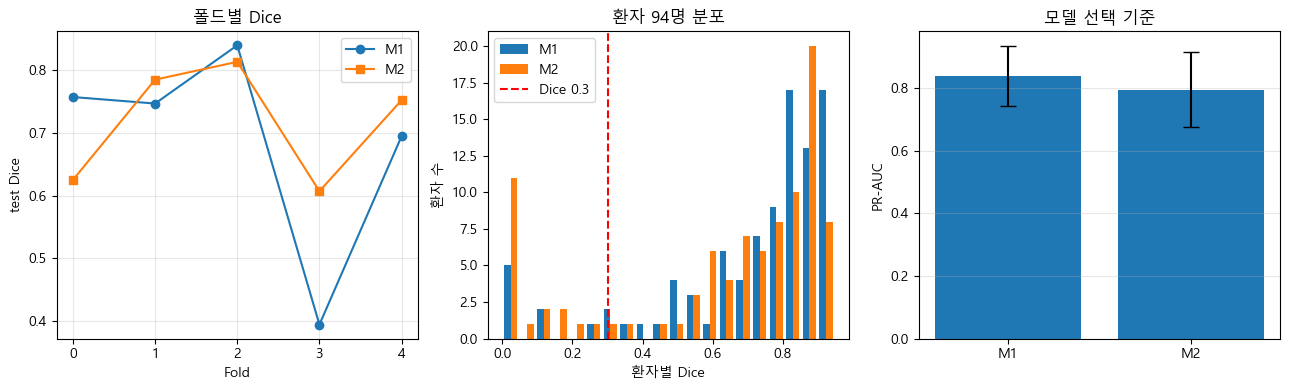

In [ ]:
# [본인] 폴드별 Dice / 환자 분포 시각화
plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
plt.plot(cv1["fold"], cv1["dice"], "o-", label="M1")
plt.plot(cv2_["fold"], cv2_["dice"], "s-", label="M2")
plt.xlabel("Fold"); plt.ylabel("test Dice"); plt.title("폴드별 Dice")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist([s1.values, s2.values], bins=20, label=["M1","M2"])
plt.axvline(0.3, ls="--", c="r", label="Dice 0.3")
plt.xlabel("환자별 Dice"); plt.ylabel("환자 수")
plt.title(f"환자 {len(s1)}명 분포"); plt.legend()

plt.subplot(1, 3, 3)
plt.bar(["M1","M2"], [cv1["prauc"].mean(), cv2_["prauc"].mean()],
        yerr=[cv1["prauc"].std(), cv2_["prauc"].std()], capsize=6)
plt.ylabel("PR-AUC"); plt.title("모델 선택 기준"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

---
# 11. 심화 분석

`# [배지수]` 환자 3D Dice, TP·FP·FN·TN 픽셀 분석, 종양 크기 구간별 성능.

## 11-1. 환자 3D Dice

환자의 모든 슬라이스를 하나의 3차원 덩어리로 보고 Dice 를 계산한다.
슬라이스별 Dice 평균보다 임상적 의미가 크다 — 실제 종양은 3차원 구조이기 때문이다.

In [ ]:
# [배지수] 환자 3D Dice + 부트스트랩 신뢰구간
p3d = best_sl.groupby("patient")[["tp","fp","fn","tn"]].sum()
p3d["dice3d"] = 2*p3d["tp"] / (2*p3d["tp"] + p3d["fp"] + p3d["fn"]).clip(lower=1)

rng = np.random.default_rng(SEED)
vals = p3d["dice3d"].to_numpy()
boot = [vals[rng.integers(0, len(vals), len(vals))].mean() for _ in range(10000)]
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"환자 3D Dice  (n={len(p3d)})")
print(f"  평균 {vals.mean():.4f}   중앙값 {np.median(vals):.4f}   최소 {vals.min():.4f}")
print(f"  95% 부트스트랩 CI [{lo:.4f}, {hi:.4f}]")
print()
print("슬라이스 평균 Dice 와 비교")
print(f"  3D Dice        {vals.mean():.4f}")
print(f"  환자별 Dice     {pd.Series(best_pd).mean():.4f}")

환자 3D Dice  (n=94)
  평균 0.7084   중앙값 0.8075   최소 0.0000
  95% 부트스트랩 CI [0.6567, 0.7555]

슬라이스 평균 Dice 와 비교
  3D Dice        0.7084
  환자별 Dice     0.7084


## 11-2. TP · FP · FN · TN 픽셀 분석

오탐과 놓침을 픽셀 단위로 분해한다. 실패 유형 분석(12절)의 정량적 근거가 된다.

픽셀 수 confusion matrix
        예측 종양     예측 배경
실제 종양  433627    144919
실제 배경  271392  54527982

실제 클래스별 비율(%)
       예측 종양  예측 배경
실제 종양  74.95  25.05
실제 배경   0.50  99.50

  TP  맞힌 종양           433,627
  FN  놓친 종양           144,919   (종양의 25.0%)
  FP  가짜 종양           271,392
  TN  맞힌 정상        54,527,982


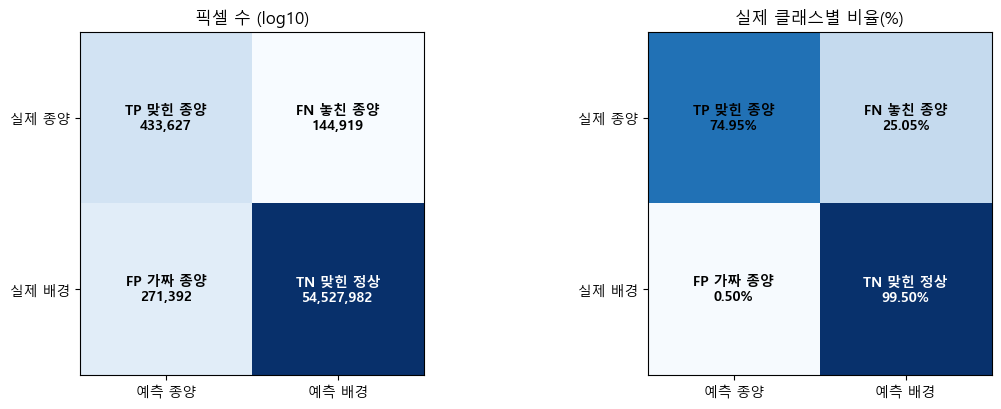

In [ ]:
# [배지수] 픽셀 수준 confusion matrix
tot = best_sl[["tp","fp","fn","tn"]].sum()
conf = pd.DataFrame({"예측 종양": [tot.tp, tot.fp],
                     "예측 배경": [tot.fn, tot.tn]},
                    index=["실제 종양", "실제 배경"])
print("픽셀 수 confusion matrix")
print(conf.to_string())
print()
row_pct = conf.div(conf.sum(axis=1), axis=0) * 100
print("실제 클래스별 비율(%)")
print(row_pct.round(2).to_string())
print()
print(f"  TP  맞힌 종양      {tot.tp:>12,}")
print(f"  FN  놓친 종양      {tot.fn:>12,}   (종양의 {tot.fn/(tot.tp+tot.fn)*100:.1f}%)")
print(f"  FP  가짜 종양      {tot.fp:>12,}")
print(f"  TN  맞힌 정상      {tot.tn:>12,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].imshow(np.log10(conf.to_numpy() + 1), cmap="Blues")
axes[0].set_title("픽셀 수 (log10)")
axes[1].imshow(row_pct.to_numpy(), cmap="Blues", vmin=0, vmax=100)
axes[1].set_title("실제 클래스별 비율(%)")
names = np.array([["TP 맞힌 종양", "FN 놓친 종양"], ["FP 가짜 종양", "TN 맞힌 정상"]])
for ax, vv, fmt in [(axes[0], conf.to_numpy(), ","), (axes[1], row_pct.to_numpy(), ".2f")]:
    ax.set_xticks([0,1], conf.columns); ax.set_yticks([0,1], conf.index)
    for r in range(2):
        for c in range(2):
            lab = f"{vv[r,c]:{fmt}}" + ("%" if fmt == ".2f" else "")
            ax.text(c, r, f"{names[r,c]}\n{lab}", ha="center", va="center",
                    color="white" if (r==1 and c==1) else "black", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## 11-3. 종양 크기 구간별 성능

상관계수만으로는 "작은 종양을 못 찾는다"를 정량화하기 어렵다. 구간으로 나눠 본다.

       슬라이스수  평균_Dice  중앙값_Dice   평균_놓친픽셀   평균_종양픽셀
크기그룹                                               
작은 종양    397   0.4828    0.6214   42.2065  125.1209
중간 종양    397   0.7262    0.8553  104.7103  397.4937
큰 종양     398   0.7810    0.8904  217.5704  932.3317

작은 종양 vs 큰 종양 Dice 차이: 0.2982


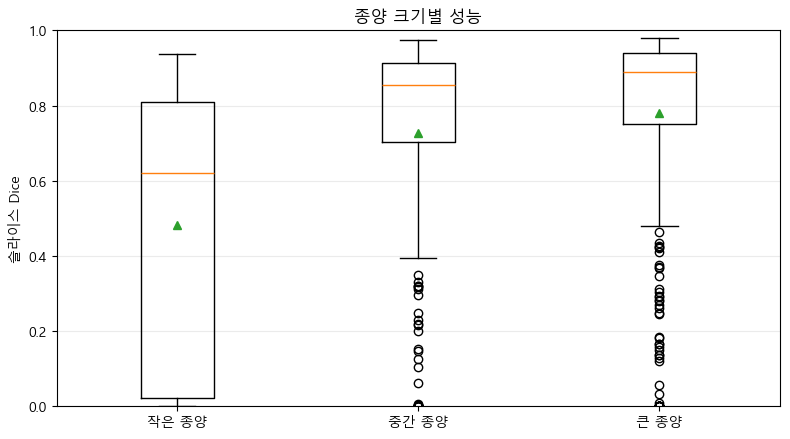

In [ ]:
# [배지수] 종양 크기 3분위별 성능
pos_sl = best_sl[best_sl.tumor_px > 0].copy()
pos_sl["크기그룹"] = pd.qcut(pos_sl.tumor_px, q=3,
                             labels=["작은 종양","중간 종양","큰 종양"], duplicates="drop")
size_sum = pos_sl.groupby("크기그룹", observed=True).agg(
    슬라이스수=("dice","size"), 평균_Dice=("dice","mean"),
    중앙값_Dice=("dice","median"), 평균_놓친픽셀=("fn","mean"),
    평균_종양픽셀=("tumor_px","mean")).round(4)
print(size_sum.to_string())
print()
print(f"작은 종양 vs 큰 종양 Dice 차이: "
      f"{size_sum.loc['큰 종양','평균_Dice'] - size_sum.loc['작은 종양','평균_Dice']:.4f}")

plt.figure(figsize=(8, 4.5))
groups = [pos_sl.loc[pos_sl["크기그룹"] == l, "dice"].to_numpy()
          for l in ["작은 종양","중간 종양","큰 종양"]]
boxplot_compat(plt.gca(), groups, ["작은 종양","중간 종양","큰 종양"], showmeans=True)
plt.ylim(0, 1); plt.ylabel("슬라이스 Dice")
plt.title("종양 크기별 성능"); plt.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

---
# 12. 오류 분석과 가설검정

`# [본인]` 실패 유형 분류, 임계값 민감도, 통계 검정.

th train:   0%|          | 0/2440 [00:00<?, ?it/s]

th val:   0%|          | 0/421 [00:00<?, ?it/s]

  th   dice  recall  vol_ratio
0.05 0.5765  0.8652     2.0013
0.10 0.6485  0.8459     1.6087
0.15 0.6862  0.8313     1.4229
0.20 0.7102  0.8184     1.3045
0.25 0.7265  0.8055     1.2176
0.30 0.7384  0.7936     1.1494
0.35 0.7474  0.7824     1.0936
0.40 0.7551  0.7717     1.0438
0.45 0.7596  0.7596     0.9999
0.50 0.7631  0.7471     0.9582
0.55 0.7660  0.7352     0.9195
0.60 0.7663  0.7206     0.8806
0.65 0.7655  0.7045     0.8406
0.70 0.7617  0.6859     0.8011
0.75 0.7548  0.6645     0.7608
0.80 0.7450  0.6398     0.7176
0.85 0.7286  0.6068     0.6655
0.90 0.6973  0.5555     0.5933
0.95 0.6308  0.4687     0.4859

th=0.50 Dice 0.7631  |  최고 0.7663 (th=0.60)  |  개선폭 +0.0033
고원 중앙 임계값 0.57


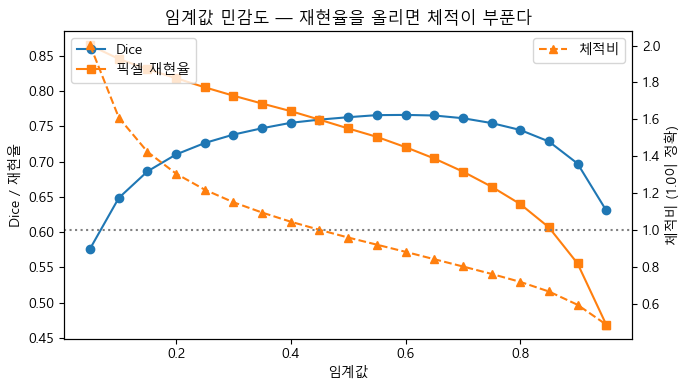

In [ ]:
# [본인] 임계값 민감도 — 조정은 성능 향상이 아니라 운영점 이동
#         마지막 폴드 모델로 확인 (전체 재학습 불필요)
f_last = K_FOLDS - 1
test_p = df.loc[df.fold == f_last, "patient"].unique()
rest_p = df.loc[df.fold != f_last, "patient"].unique()
tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)
sub_va = df[df.patient.isin(va_p)].reset_index(drop=True)
arr_tr = build_dataset(df[df.patient.isin(tr_p)].reset_index(drop=True), "th train")
mean_l, std_l = compute_norm_stats(arr_tr[0]); del arr_tr; gc.collect()
arr_va = build_dataset(sub_va, "th val")
va_ds = SegDataset(*arr_va, sub_va, mean_l, std_l, neg_ratio=None)
va_ld = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

m_last = UNet(base=BASE, use_bn=(BEST == "M2")).to(device)
m_last.load_state_dict(torch.load(f"lgg_{BEST}_f{f_last}.pt", map_location=device))
vp, vt = evaluate_seg(m_last, va_ld)
sw = threshold_sweep(vp, vt)
print(sw.round(4).to_string(index=False))
print()
print(f"th=0.50 Dice {sw.loc[sw.th==0.50,'dice'].values[0]:.4f}  |  "
      f"최고 {sw['dice'].max():.4f} (th={sw.loc[sw['dice'].idxmax(),'th']:.2f})  |  "
      f"개선폭 {sw['dice'].max() - sw.loc[sw.th==0.50,'dice'].values[0]:+.4f}")
print(f"고원 중앙 임계값 {pick_threshold(sw):.2f}")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sw["th"], sw["dice"], "o-", label="Dice")
ax1.plot(sw["th"], sw["recall"], "s-", label="픽셀 재현율")
ax1.set_xlabel("임계값"); ax1.set_ylabel("Dice / 재현율"); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(sw["th"], sw["vol_ratio"], "^--", color="tab:orange", label="체적비")
ax2.axhline(1.0, ls=":", c="gray"); ax2.set_ylabel("체적비 (1.0이 정확)")
ax2.legend(loc="upper right")
plt.title("임계값 민감도 — 재현율을 올리면 체적이 부푼다")
plt.tight_layout(); plt.show()

In [ ]:
# [본인] 실패 유형 분류 — 상·하위 환자
ps = pd.Series(best_pd, name="dice").to_frame()
ps["inst"] = [p.split("_")[1] for p in ps.index]
pv = best_sl.groupby("patient").agg(
    슬라이스=("dice","size"), 종양슬라이스=("tumor_px", lambda x: (x>0).sum()),
    평균종양px=("tumor_px", lambda x: x[x>0].mean() if (x>0).any() else 0),
    체적비=("pred_px", "sum"))
pv["체적비"] = pv["체적비"] / best_sl.groupby("patient")["tumor_px"].sum().clip(lower=1)
ps = ps.join(pv)

print("=== 하위 5명 ===")
print(ps.nsmallest(5, "dice").round(3).to_string())
print()
print("=== 상위 5명 ===")
print(ps.nlargest(5, "dice").round(3).to_string())
print()
c = ps[["dice","종양슬라이스","평균종양px"]].corr()["dice"]
print("환자별 Dice 와의 상관")
print(f"  종양 슬라이스 수  {c['종양슬라이스']:+.3f}  (설명력 {c['종양슬라이스']**2*100:.1f}%)")
print(f"  평균 종양 크기    {c['평균종양px']:+.3f}  (설명력 {c['평균종양px']**2*100:.1f}%)")

=== 하위 5명 ===
                        dice inst  슬라이스  종양슬라이스   평균종양px     체적비
TCGA_DU_7306_19930512  0.000   DU    42      13  404.846   0.000
TCGA_HT_7860_19960513  0.000   HT    22       6  160.500   0.000
TCGA_HT_A5RC_19990831  0.013   HT    32      15  285.800   0.007
TCGA_HT_A61A_20000127  0.013   HT    88      37  371.243   0.007
TCGA_FG_A60K_20040224  0.026   FG    73      24   81.667  76.873

=== 상위 5명 ===
                        dice inst  슬라이스  종양슬라이스   평균종양px    체적비
TCGA_HT_8114_19981030  0.941   HT    22      11  684.818  0.922
TCGA_DU_6401_19831001  0.938   DU    51      25  802.920  1.051
TCGA_DU_6399_19830416  0.934   DU    53      19  333.632  1.058
TCGA_DU_5871_19941206  0.933   DU    36      15  637.933  1.061
TCGA_CS_6667_20011105  0.932   CS    20       8  251.250  1.050

환자별 Dice 와의 상관
  종양 슬라이스 수  +0.004  (설명력 0.0%)
  평균 종양 크기    +0.258  (설명력 6.6%)


대응표본 순열검정 (100,000회 무작위, 환자 n=94)
  M1 중앙값 0.8075  /  M2 중앙값 0.7516
  중앙값 차이 (M2-M1)  -0.0269
  M2 가 나은 환자      30 / 94
  p = 0.0009   95% CI [-0.1283, -0.0343]

판정: H0 기각
주의: n이 작으면 검정력이 낮다. p값과 함께 중앙값 차이·신뢰구간을 보고할 것


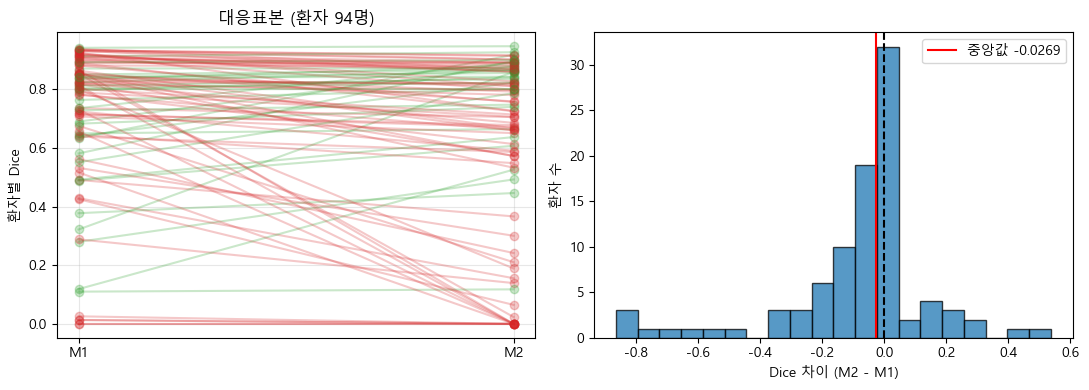

In [ ]:
# [본인] 가설검정 — 환자 단위 대응표본
#         검정 단위가 슬라이스가 아니라 환자인 이유:
#         동일 환자의 인접 슬라이스는 거의 같은 영상이라 독립 표본이 아니다
def perm_test(diff, n_perm=100000, seed=SEED):
    n = len(diff)
    if n <= 22:                                   # 전수 계산 가능
        signs = ((np.arange(2**n)[:, None] >> np.arange(n)) & 1) * 2 - 1
        null = (signs * np.abs(diff)).mean(axis=1)
        return float((np.abs(null) >= abs(diff.mean()) - 1e-12).mean()), "전수"
    rng = np.random.default_rng(seed)
    null = [(rng.choice([-1, 1], n) * np.abs(diff)).mean() for _ in range(n_perm)]
    return float((np.abs(null) >= abs(diff.mean()) - 1e-12).mean()), f"{n_perm:,}회 무작위"

def boot_ci(diff, n_boot=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    b = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(n_boot)]
    return np.percentile(b, [2.5, 97.5])

pat = sorted(set(pd1) & set(pd2))
a = np.array([pd1[p] for p in pat]); b = np.array([pd2[p] for p in pat])
diff = b - a
p_val, method = perm_test(diff)
lo_, hi_ = boot_ci(diff)

print(f"대응표본 순열검정 ({method}, 환자 n={len(pat)})")
print(f"  M1 중앙값 {np.median(a):.4f}  /  M2 중앙값 {np.median(b):.4f}")
print(f"  중앙값 차이 (M2-M1)  {np.median(diff):+.4f}")
print(f"  M2 가 나은 환자      {(diff>0).sum()} / {len(pat)}")
print(f"  p = {p_val:.4f}   95% CI [{lo_:+.4f}, {hi_:+.4f}]")
print()
print("판정:", "H0 기각" if p_val < 0.05 else "H0 기각 실패 — '차이 없음'이 아니라 '차이를 확인하지 못함'")
print("주의: n이 작으면 검정력이 낮다. p값과 함께 중앙값 차이·신뢰구간을 보고할 것")

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for i in range(len(pat)):
    plt.plot([0, 1], [a[i], b[i]], "o-", alpha=0.25,
             color="tab:green" if diff[i] > 0 else "tab:red")
plt.xticks([0, 1], ["M1", "M2"]); plt.ylabel("환자별 Dice")
plt.title(f"대응표본 (환자 {len(pat)}명)"); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist(diff, bins=20, edgecolor="k", alpha=0.75)
plt.axvline(0, ls="--", c="k"); plt.axvline(np.median(diff), c="r",
                                            label=f"중앙값 {np.median(diff):+.4f}")
plt.xlabel("Dice 차이 (M2 - M1)"); plt.ylabel("환자 수"); plt.legend()
plt.tight_layout(); plt.show()

---
# 13. 결과 저장

In [ ]:
# [본인] results.json
summary = {
    "환경": ENV,
    "설정": {"IMAGE_SIZE": IMAGE_SIZE, "MIN_PX": MIN_PX, "K_FOLDS": K_FOLDS,
             "BASE": BASE, "BATCH": BATCH_SIZE, "EPOCHS": EPOCHS,
             "NEG_RATIO": NEG_RATIO, "LR": BEST_LR, "LOSS": BEST_LOSS, "SEED": SEED},
    "소실검증": {"완전소실": int((sz["small"]==0).sum()),
                 "5px미만": int((sz["small"]<5).sum()),
                 "평균축소율": float(sz["ratio"].mean())},
    "M0": M0_RESULT,
    "M1_폴드평균": {k: float(cv1[k].mean()) for k in
                    ["dice","dice_pos","iou","recall","precision","prauc","vol"]},
    "M2_폴드평균": {k: float(cv2_[k].mean()) for k in
                    ["dice","dice_pos","iou","recall","precision","prauc","vol"]},
    "폴드간표준편차": {"M1_dice": float(cv1["dice"].std()),
                       "M2_dice": float(cv2_["dice"].std())},
    "환자110명": {"M1_평균": float(s1.mean()), "M1_표준편차": float(s1.std()),
                  "M1_Dice03미만": int((s1<0.3).sum()),
                  "M2_평균": float(s2.mean()), "M2_표준편차": float(s2.std()),
                  "M2_Dice03미만": int((s2<0.3).sum())},
    "3D_Dice": {"평균": float(vals.mean()), "CI95": [float(lo), float(hi)]},
    "검정": {"n": len(pat), "p": p_val, "중앙값차이": float(np.median(diff)),
             "CI95": [float(lo_), float(hi_)]},
    "최종모델": BEST,
}
with open("results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
best_sl.to_csv("slice_records.csv", index=False, encoding="utf-8-sig")
pd.Series(best_pd, name="dice").to_csv("patient_dice.csv", encoding="utf-8-sig")
print("results.json / slice_records.csv / patient_dice.csv 저장 완료")
print(json.dumps(summary, ensure_ascii=False, indent=2)[:1800])

results.json / slice_records.csv / patient_dice.csv 저장 완료
{
  "환경": {
    "OS": "Windows 10",
    "Python": "3.10.11",
    "torch": "2.11.0+cu128",
    "CUDA": "12.8",
    "GPU": "NVIDIA GeForce RTX 5060 Laptop GPU",
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "opencv": "4.11.0",
    "sklearn": "1.7.2",
    "matplotlib": "3.10.9",
    "SEED": 42
  },
  "설정": {
    "IMAGE_SIZE": 128,
    "MIN_PX": 5,
    "K_FOLDS": 5,
    "BASE": 32,
    "BATCH": 16,
    "EPOCHS": 30,
    "NEG_RATIO": 1.0,
    "LR": 0.001,
    "LOSS": "BCE",
    "SEED": 42
  },
  "소실검증": {
    "완전소실": 0,
    "5px미만": 2,
    "평균축소율": 0.25033985385880914
  },
  "M0": {
    "dice": 0.13098330212888104,
    "pixel_recall": 0.44493436995502517,
    "vol": 5.7937571083371076,
    "slice_recall": 1.0,
    "slice_precision": 0.3669950738916256,
    "bg_accuracy": 0.9895527676012389
  },
  "M1_폴드평균": {
    "dice": 0.6860791960599573,
    "dice_pos": 0.7300117643187386,
    "iou": 0.5406378473156656,
    "recall": 0.8781362

---
# 14. 참고 — 사전학습 인코더 적용 가능성

`# [윤동길]` **본 연구 범위 밖의 예비 실험이다.**

본 연구는 수업에서 다룬 라이브러리 범위(`torch`, `numpy`, `pandas`, `cv2`,
`matplotlib`, `seaborn`, `sklearn`, `tqdm`) 내로 구현을 제한하였다.
성능 상한을 가늠하기 위해 별도로 `segmentation_models_pytorch` 의
ResNet34 ImageNet 사전학습 인코더를 적용한 예비 실험을 수행하였다.

## 실측 결과 (동일 5-Fold 조건, 128px, 10에폭)

| | 베이스라인 U-Net | 전이학습 (ResNet34) |
|---|---|---|
| pooled tumor Dice | 0.7131 | **0.8235** |
| pooled tumor IoU | 0.5541 | 0.7000 |
| Fold 평균 Dice | 0.7051 ± 0.0869 | 0.8200 ± 0.0334 |
| 환자별 평균 Dice | 0.5785 | 0.6851 |

환자 110명 대응표본 t검정에서 평균 차이 0.1066, p < 0.000001 로 유의하였다.

## 해석과 한계

- Fold 간 표준편차가 0.0869 에서 0.0334 로 감소하여 **안정성도 개선**되었다.
- 다만 이 향상은 **사전학습 효과와 디코더 아키텍처 차이가 혼재**된 값이다.
  `smp.Unet` 은 본 연구의 U-Net 과 디코더 구조·파라미터 수가 모두 다르다.
- 본 연구의 범위 제약상 **주 결과에는 포함하지 않으며**, 향후 과제로 남긴다.

아래 셀은 참고용이며 실행하지 않아도 무방하다.

In [ ]:
# [윤동길] 참고 실험 — 본 연구 범위 밖. 실행하려면 아래 주석을 해제할 것
# import segmentation_models_pytorch as smp
#
# def make_transfer_model():
#     return smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
#                     in_channels=3, classes=1)
#
# cv_tr, pd_tr, sl_tr = run_cv(criterion_name="BCE+Dice", tag="TRANSFER")

print("참고 실험 셀 — 실행하지 않음 (본 연구 범위 밖)")

참고 실험 셀 — 실행하지 않음 (본 연구 범위 밖)


---
## 14-1. 참고 — 입력 크기 비교 (128px vs 256px)

`# [이정우]` **본 연구 설정의 근거를 보강하는 참고 실험이다.**

2절에서 128px 축소 시 종양 소실이 0장임을 확인하였다.
다만 **소실이 없다는 것과 성능이 동등하다는 것은 다른 문제**이므로,
폴드 하나에서 두 조건을 직접 비교한다.

| 조건 | 값 |
|---|---|
| 폴드 | fold 0 (K-Fold 대상 94명 기준) |
| 에폭 | 60 — 수렴 확인용 |
| 손실 · 학습률 | BCE · lr = 1e-3 (M1 과 동일) |
| MIN_PX | 면적 비율 환산 (128px → 5 / 256px → 20) |

계산 비용상 5-Fold 전체가 아닌 **폴드 1개**로 수행하므로
결과는 방향성 확인 용도로만 해석한다.

> **구현 주의** — `build_dataset` 의 `size` 기본값은 셀 실행 시점의 `IMAGE_SIZE` 로 고정된다.
> 전역 변수를 바꿔도 반영되지 않으므로 `size=` 를 명시적으로 전달해야 한다.

In [ ]:
# ============================================================
# [본인] 입력 크기 비교 — 128px vs 256px (폴드 1개 · 수렴까지)
#        14절 참고 실험 뒤 · 15절 결론 앞에 배치
#
#   [주의] build_dataset 의 size 기본값은 셀 실행 시점 IMAGE_SIZE 로 고정된다.
#          전역을 바꿔도 반영되지 않으므로 size= 를 명시적으로 넘긴다.
# ============================================================

SZ_EPOCHS = 60          # 30에폭에서는 256px 이 미수렴이므로 수렴까지 학습

def run_size_fold(image_size, min_px, tag, f=0):
    """폴드 f 를 test 로 쓰고 지정 입력 크기로 학습·평가한다."""
    global MIN_PX
    _bak_min = MIN_PX
    MIN_PX = min_px
    try:
        # ---------- 분할 (K-Fold 대상 94명 안에서만) ----------
        test_p = df.loc[(df.fold == f) & df.patient.isin(kfold_patients),
                        "patient"].unique()
        rest_p = np.array([p for p in kfold_patients if p not in set(test_p)])
        tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)

        sub = {k: df[df.patient.isin(v)].reset_index(drop=True)
               for k, v in [("train", tr_p), ("val", va_p), ("test", test_p)]}

        # ---------- 적재 (size 명시 필수) ----------
        arr = {k: build_dataset(sub[k], f"{tag} {k}", size=image_size) for k in sub}
        assert arr["train"][0].shape[1] == image_size, \
               f"적재 크기 불일치 {arr['train'][0].shape[1]} != {image_size}"
        print(f"  [{tag}] 적재 {arr['train'][0].shape}  "
              f"train {len(tr_p)}명 / val {len(va_p)}명 / test {len(test_p)}명")

        # ---------- 학습 ----------
        mean, std = compute_norm_stats(arr["train"][0])
        tr_ds = SegDataset(*arr["train"], sub["train"], mean, std,
                           neg_ratio=NEG_RATIO, augment=True)
        va_ds = SegDataset(*arr["val"],   sub["val"],   mean, std, neg_ratio=None)
        te_ds = SegDataset(*arr["test"],  sub["test"],  mean, std, neg_ratio=None)
        kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
        va_ld = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, **kw)
        te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, **kw)

        t0 = time.time()
        model, hist = train_unet(BCELoss(), tr_ds, tr_ld, va_ld,
                                 use_bn=False, epochs=SZ_EPOCHS,
                                 lr=BEST_LR, tag=tag)
        sec = time.time() - t0

        # ---------- 평가 (임계값은 val 에서만) ----------
        vp, vt = evaluate_seg(model, va_ld)
        t = pick_threshold(threshold_sweep(vp, vt))
        tp_, tt_ = evaluate_seg(model, te_ld)
        has  = sub["test"]["tumor"].values.astype(bool)
        pf   = ((tp_ > t).sum(axis=(1, 2)) > min_px).astype(int)
        area = (tp_ > t).sum(axis=(1, 2)) / image_size**2

        # ---------- 수렴 판정 : 마지막 10에폭 val Dice 기울기 ----------
        v = np.array(hist["val_dice"])
        slope = float(np.polyfit(np.arange(10), v[-10:], 1)[0]) if len(v) >= 10 else np.nan

        r = {"입력": f"{image_size}px", "MIN_PX": min_px, "th": round(t, 2),
             "Dice":      round(float(dice_score(tp_, tt_, t)), 4),
             "Dice_pos":  round(float(dice_score(tp_[has], tt_[has], t)), 4),
             "recall":    round(recall_score(has.astype(int), pf, zero_division=0), 4),
             "precision": round(precision_score(has.astype(int), pf, zero_division=0), 4),
             "PR_AUC":    round(average_precision_score(has.astype(int), area), 4),
             "최고val":    round(float(v.max()), 4),
             "말기기울기":  round(slope, 5),
             "에폭평균초":  round(float(np.mean(hist["sec"])), 1),
             "총시간분":    round(sec / 60, 1)}

        del arr, tr_ds, va_ds, te_ds, model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
        return r
    finally:
        MIN_PX = _bak_min          # 전역 복원 — 이후 셀 오염 방지


# ---------- 실행 ----------
print(f"입력 크기 비교 — fold 0 · {SZ_EPOCHS}에폭 · 동일 시드\n")
sz_res = [run_size_fold(128,  5, "SZ128"),
          run_size_fold(256, 20, "SZ256")]

print()
sz_df = pd.DataFrame(sz_res)
print(sz_df.to_string(index=False))

# ---------- 수렴 판정 ----------
print("\n[수렴 판정] 마지막 10에폭 val Dice 기울기")
for r in sz_res:
    state = "수렴" if abs(r["말기기울기"]) < 0.001 else "상승 중 — 에폭 부족"
    print(f"  {r['입력']:>6}  기울기 {r['말기기울기']:+.5f}   {state}")

# ---------- 해석 ----------
d128, d256 = sz_res[0]["Dice"], sz_res[1]["Dice"]
r128, r256 = sz_res[0]["recall"], sz_res[1]["recall"]
t128, t256 = sz_res[0]["총시간분"], sz_res[1]["총시간분"]

print("\n[해석]")
print(f"  Dice      128px {d128:.4f}  vs  256px {d256:.4f}   차이 {d128-d256:+.4f}")
print(f"  recall    128px {r128:.4f}  vs  256px {r256:.4f}   차이 {r128-r256:+.4f}")
print(f"  학습시간   128px {t128:.1f}분  vs  256px {t256:.1f}분   "
      f"({t256/max(t128,0.1):.1f}배)")
print()
if d128 >= d256:
    print("  -> 동일 조건에서 128px 이 우세하거나 동등하다.")
    print("     소실 검증 결과(0장)와 함께 128px 채택의 근거로 사용한다.")
else:
    print("  -> 256px 이 우세하다. 128px 채택은 계산 예산상의 선택이며,")
    print("     성능 상한을 일부 포기한 것임을 한계에 명시한다.")

# ---------- 전역 복원 확인 ----------
assert MIN_PX == 5, f"MIN_PX 복원 실패 (현재 {MIN_PX})"
assert IMAGE_SIZE == 128, f"IMAGE_SIZE 가 변경됨 (현재 {IMAGE_SIZE})"
print(f"\n전역 확인 — IMAGE_SIZE={IMAGE_SIZE}, MIN_PX={MIN_PX} (변경 없음)")

입력 크기 비교 — fold 0 · 60에폭 · 동일 시드



SZ128 train:   0%|          | 0/2197 [00:00<?, ?it/s]

SZ128 val:   0%|          | 0/380 [00:00<?, ?it/s]

SZ128 test:   0%|          | 0/803 [00:00<?, ?it/s]

  [SZ128] 적재 (2197, 128, 128, 3)  train 60명 / val 11명 / test 23명
  [SZ128]  1/60  loss 0.0530  train 0.3007  val 0.4503  3.8초
  [SZ128]  5/60  loss 0.0264  train 0.6196  val 0.5852  3.9초
  [SZ128] 10/60  loss 0.0150  train 0.8105  val 0.8114  3.9초
  [SZ128] 15/60  loss 0.0114  train 0.8496  val 0.8319  3.9초
  [SZ128] 20/60  loss 0.0101  train 0.8648  val 0.6994  3.8초
  [SZ128] 25/60  loss 0.0104  train 0.8643  val 0.5375  3.8초
  [SZ128] 30/60  loss 0.0086  train 0.8840  val 0.5805  3.9초
  [SZ128] 35/60  loss 0.0078  train 0.8937  val 0.5259  3.9초
  [SZ128] 40/60  loss 0.0074  train 0.8979  val 0.5131  3.9초
  [SZ128] 45/60  loss 0.0071  train 0.9019  val 0.5743  3.9초
  [SZ128] 50/60  loss 0.0067  train 0.9058  val 0.5442  3.9초
  [SZ128] 55/60  loss 0.0066  train 0.9063  val 0.5413  3.9초
  [SZ128] 60/60  loss 0.0065  train 0.9075  val 0.5469  3.9초
  [SZ128] 최고 val Dice 0.8319 | 에폭 평균 3.9초 | 과적합 격차 +0.3606


SZ256 train:   0%|          | 0/2197 [00:00<?, ?it/s]

SZ256 val:   0%|          | 0/380 [00:00<?, ?it/s]

SZ256 test:   0%|          | 0/803 [00:00<?, ?it/s]

  [SZ256] 적재 (2197, 256, 256, 3)  train 60명 / val 11명 / test 23명
  [SZ256]  1/60  loss 0.0582  train 0.3252  val 0.5123  14.6초
  [SZ256]  5/60  loss 0.0290  train 0.5725  val 0.6166  15.0초
  [SZ256] 10/60  loss 0.0206  train 0.7275  val 0.4940  15.0초
  [SZ256] 15/60  loss 0.0138  train 0.8180  val 0.7943  15.0초
  [SZ256] 20/60  loss 0.0128  train 0.8354  val 0.7680  15.1초
  [SZ256] 25/60  loss 0.0109  train 0.8564  val 0.4691  15.1초
  [SZ256] 30/60  loss 0.0085  train 0.8874  val 0.4485  15.1초
  [SZ256] 35/60  loss 0.0077  train 0.8956  val 0.4682  15.2초
  [SZ256] 40/60  loss 0.0072  train 0.9016  val 0.4731  15.1초
  [SZ256] 45/60  loss 0.0065  train 0.9091  val 0.4882  15.2초
  [SZ256] 50/60  loss 0.0062  train 0.9136  val 0.4686  15.1초
  [SZ256] 55/60  loss 0.0061  train 0.9141  val 0.4832  15.2초
  [SZ256] 60/60  loss 0.0060  train 0.9158  val 0.4827  15.2초
  [SZ256] 최고 val Dice 0.7943 | 에폭 평균 15.1초 | 과적합 격차 +0.4331

   입력  MIN_PX   th   Dice  Dice_pos  recall  precision  PR_AUC  최고va

In [ ]:
summary["입력크기비교"] = {
    "조건": f"fold 0 · {SZ_EPOCHS}에폭 · 동일 시드",
    "128px": sz_res[0],
    "256px": sz_res[1],
}

In [ ]:
json.dump({"입력크기비교": sz_res}, open("size_compare.json","w"),
          ensure_ascii=False, indent=2)
print("size_compare.json 저장 완료")

size_compare.json 저장 완료


In [ ]:
# ============================================================
# [본인] 128px 축소 검증 시각화 — 원본 마스크와 축소 후 마스크를 겹쳐서
#        셀 21(소실 검증) 바로 뒤에 넣을 것
#
#   왼쪽  : 대표 사례 3건을 겹쳐 표시
#            회색  = 원본 마스크 (256px)
#            초록  = 축소 후에도 살아남은 픽셀
#            빨강  = 축소로 사라진 픽셀   ← 있으면 문제
#   오른쪽 : 1,373장 전체 산점도 (원본 px vs 축소 후 px)
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- 대표 사례 3건 고르기 ----------
pos = df[df.tumor == 1].reset_index(drop=True)
picks = [
    ("가장 작은 종양",  int(pos["tumor_px"].idxmin())),
    ("중앙값 크기",     int((pos["tumor_px"] - pos["tumor_px"].median()).abs().idxmin())),
    ("가장 큰 종양",    int(pos["tumor_px"].idxmax())),
]

fig = plt.figure(figsize=(15, 4.6))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.25], wspace=0.22)

for k, (label, i) in enumerate(picks):
    mk_big = (cv2.imread(pos.loc[i, "mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)

    # 축소 → 다시 원래 크기로 복원 (겹쳐 보기 위해)
    mk_small = cv2.resize(mk_big, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
    mk_back  = cv2.resize(mk_small, mk_big.shape[::-1], interpolation=cv2.INTER_NEAREST)

    kept = (mk_big == 1) & (mk_back == 1)      # 살아남음
    lost = (mk_big == 1) & (mk_back == 0)      # 사라짐

    # 종양 주변만 확대해서 보기
    ys, xs = np.where(mk_big > 0)
    pad = max(18, int(0.35 * max(ys.ptp() + 1, xs.ptp() + 1)))
    y0, y1 = max(0, ys.min()-pad), min(mk_big.shape[0], ys.max()+pad+1)
    x0, x1 = max(0, xs.min()-pad), min(mk_big.shape[1], xs.max()+pad+1)

    canvas = np.zeros((*mk_big.shape, 3), np.float32)
    canvas[mk_big == 1] = [0.85, 0.85, 0.85]   # 원본 영역 (회색)
    canvas[kept]        = [0.10, 0.50, 0.22]   # 살아남음 (초록)
    canvas[lost]        = [0.85, 0.12, 0.16]   # 사라짐 (빨강)

    ax = fig.add_subplot(gs[0, k])
    ax.imshow(canvas[y0:y1, x0:x1], interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    n_o, n_s, n_l = int(mk_big.sum()), int(mk_small.sum()), int(lost.sum())
    ax.set_title(f"{label}\n{n_o:,}px → {n_s:,}px   사라진 픽셀 {n_l:,}",
                 fontsize=11.5, fontweight="bold",
                 color="#DA1E28" if n_s == 0 else "#161616")

# ---------- 전체 1,373장 산점도 ----------
ax = fig.add_subplot(gs[0, 3])
ax.scatter(sz["orig"], sz["small"], s=7, alpha=0.35, color="#0F62FE",
           edgecolors="none", label="종양 슬라이스")
lim = np.array([1, sz["orig"].max() * 1.15])
ax.plot(lim, lim * 0.25, color="#DA1E28", lw=2, ls="--", label="이론선 y = x/4")
ax.axhline(MIN_PX, color="#525252", lw=1.2, ls=":",
           label=f"MIN_PX = {MIN_PX}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("원본 종양 픽셀 (256px)", fontsize=10.5)
ax.set_ylabel(f"축소 후 픽셀 ({IMAGE_SIZE}px)", fontsize=10.5)
ax.set_title(f"전체 {len(sz):,}장 · 완전 소실 {int((sz['small']==0).sum())}장",
             fontsize=11.5, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.25, which="both")

# ---------- 범례 ----------
fig.legend(handles=[
    Patch(facecolor="#1A803A", label="축소 후에도 남은 픽셀"),
    Patch(facecolor="#D91F29", label="축소로 사라진 픽셀"),
    Patch(facecolor="#D9D9D9", label="원본 마스크 영역"),
], loc="lower center", ncol=3, fontsize=10.5, frameon=False,
   bbox_to_anchor=(0.38, -0.06))

plt.suptitle(f"256px → {IMAGE_SIZE}px 축소 검증 — 종양이 사라지는가",
             fontsize=13.5, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ---------- 수치 확인 ----------
print(f"완전 소실        {int((sz['small']==0).sum())}장 / {len(sz):,}장")
print(f"평균 면적 축소율  {sz['ratio'].mean():.4f}   (이론값 0.2500)")
print(f"최소 종양        {int(sz['orig'].min())}px → {int(sz.loc[sz['orig'].idxmin(),'small'])}px")

NameError: name 'df' is not defined

---
# 15. 결론

## 주요 결과

| 항목 | 값 |
|---|---|
| 최종 모델 | PR-AUC 기준 선정 (10절 참조) |
| 검증 방식 | 환자 단위 5-Fold, 환자 110명 전원 평가 |
| 입력 크기 | 128×128 (소실 검증 통과) |

## 도달 수준 — 도메인 기준과의 비교

| 기준 | Dice | 출처 |
|---|---|---|
| BraTS 2020 우승 (nnU-Net) | 0.8895 | Isensee et al., arXiv 2011.00848 |
| 이 데이터셋 원논문 — "인간 수준에 필적" | 0.82 | Buda et al., Comput Biol Med 2019 |
| **인간 판독자 간 일치도** | **0.74 ~ 0.85** | Menze et al., IEEE TMI 2015 (BraTS) |
| 간세포암 판독자 간 / 동일인 재판독 | 0.79 / 0.85 | PMC9772368 (p<0.001) |
| 참고 실험 (전이학습) | 0.8235 | 14절 |
| 규칙 기반 (M0) | 8절 참조 | — |

**전문가 판독자끼리도 Dice 0.74~0.85 로만 일치한다.** Dice 1.0 은 도달 가능한 목표가 아니다.
BraTS 논문은 저등급 종양이 T1c 조영증강 부재로 분할 신호가 약함을 지적하며,
**본 데이터셋은 전부 저등급이다.**

## 본 연구가 수행한 검증

1. **방법론적 엄밀성** — 환자 단위 층화 분할, 슬라이스 분할 시 100% 누수 실증,
   폴드별 정규화 통계·임계값 재계산으로 누수 차단
2. **입력 크기 사전 검증** — 128px 축소 시 종양 소실 0장 확인, MIN_PX 면적 비율 환산
3. **지표의 타당성** — 규칙 기반 베이스라인으로 픽셀 정확도와 재현율 단독 사용의 부당성 실증
4. **결과의 안정성** — 5-Fold 로 환자 110명 전원 평가, 폴드 간 표준편차 보고
5. **심화 분석** — 3D Dice, 픽셀 수준 오류 분해, 종양 크기 구간별 성능

## 한계

| 항목 | 내용 |
|---|---|
| 표본 크기 | 환자 110명. 폴드 간 편차가 크면 단일 값으로 보고하기 어렵다 |
| 2D 처리 | 슬라이스 간 3차원 연속성을 입력 단계에서 활용하지 못했다 |
| 후처리 미적용 | 원논문은 최대 연결성분 후처리를 적용한다 |
| 전이학습 제외 | 라이브러리 범위 제약. 14절에 예비 결과만 제시 |
| EZ 기관 | 환자 1명으로 기관별 일반화 판단 불가 |
| 정답의 성격 | FLAIR 이상 소견이지 병리학적 경계가 아니며 관찰자 변동이 존재한다 |

## 향후 과제

- 최대 연결성분 후처리 적용 (원논문 방식)
- 2.5D 또는 3D 입력으로 슬라이스 간 연속성 활용
- 사전학습 인코더를 수업 범위 내(`timm`)에서 재구현
- 다기관 외부 데이터 검증